In [2]:
#EVENT RATE FUNCTIONS CELL (Run on startup)

import target_io
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import os
import matplotlib.colors as colors
import matplotlib.patches as patches
from numba import njit


#get the reader object with your r0_file_path, chosen pedestal path, and r1_file_path if one exists

def get_reader(r0_path, tcal_path, r1_path):

    tcal_ped_path = tcal_path

    r0_file_path = r0_path

    file_path = r1_path
    
    os.system(f"apply_calibration_SCT -p {tcal_ped_path} -i {r0_file_path} -o {file_path}") # This will calibrate the data and make a r1 file
        
    reader = target_io.WaveformArrayReader(file_path)
    return reader

#start of stat collection sequence

def read_wfs(calfile, save=False, reader = None):
    if reader == None:
        reader = target_io.WaveformArrayReader(calfile, silent=True)
    all_wfs=[]
    times = []
    for ev in range(reader.fNEvents):
        wfs = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
        reader.GetR1Event(ev, wfs)
        times.append(float(reader.fTACK_time))
        all_wfs.append(wfs)
    all_wfs = np.array(all_wfs)
    if save:
        np.save(calfile.replace(".tio",".npy"), all_wfs)
    for wf in all_wfs:
        wf[4*64 + 14, :] = np.nan
        # for l in range(64):
        wf[5*64:6*64, :] = np.nan
        wf[13*64:14*64, :] = np.nan
        wf[21*64:, :] = np.nan
    return all_wfs, times

@njit
def get_max_time(all_wfs):
    t_maxs = np.zeros(all_wfs.shape[:-1]) # shape (n_events, n_channels)
    t_maxs[:, :] = np.argmax(all_wfs[:, :], axis=-1) # find the index of the maximum value along the time axis for each event and channel
    return t_maxs

@njit
def get_int_charges(all_wfs, int_win=2, charge_ceiling = None):
    n_events, n_channels, n_samples = all_wfs.shape
    int_charge = np.zeros((n_events, n_channels))
    for ev in range(n_events):
        for ch in range(n_channels):
            t_max = np.argmax(all_wfs[ev, ch])
            if t_max > n_samples - int_win - 1:
                t_max = n_samples - int_win - 1
            elif t_max < int_win:
                t_max = int_win
            int_charge[ev, ch] = all_wfs[ev, ch, t_max-int_win:t_max+int_win+1].sum()
        if charge_ceiling != None:
            for ch in range(n_channels):
                if int_charge[ev, ch] < charge_ceiling:
                    int_charge[ev, ch] = np.nan
    return int_charge


@njit
def get_event_stats(int_charges, peak_times):
    A = 30
    B = 15
    n_events, n_channels = int_charges.shape
    chg_means = np.zeros(n_events)
    chg_sums = np.zeros(n_events)
    chg_stds = np.zeros(n_events)
    time_means = np.zeros(n_events)
    time_stds = np.zeros(n_events)
    for n, chg_ev,  time_ev in zip(range(n_events), int_charges, peak_times):
        chg_means[n] = np.nanmean(chg_ev)
        chg_sums[n] = np.nansum(chg_ev)
        chg_stds[n] = np.nanstd(chg_ev)
        time_means[n] = np.nanmean(time_ev)
        time_stds[n] = np.nanstd(time_ev)

    return time_means, time_stds, chg_means, chg_stds

def collect_stats(reader):

    all_wfs, timess = read_wfs(None, reader=reader)
    int_charges = get_int_charges(all_wfs, int_win=4)
    peak_times = get_max_time(all_wfs)
    stats_all = get_event_stats(int_charges, peak_times)


    return all_wfs, stats_all[0], stats_all[1], stats_all[2], stats_all[3], timess

#returns the sr_data object which is sr[0]: all wfs, sr[1]: mean time, sr[1][ev]: mean time for an event, sr[2]: time std
#sr[3]: charge mean, sr[4]: charge std, sr[5]: event time

def get_cuts():
    chshowx_max=1250
    chshowx_min=40
    chshowy_max=2000
    chshowy_min=40

    chflashx_max=3750
    chflashx_min=2000
    chflashy_max=1750
    chflashy_min=800

    tshowx_max=1250
    tshowx_min=0
    tshowy_max=21
    tshowy_min=14

    tflashx_max=3750
    tflashx_min=2000
    tflashy_max=18
    tflashy_min=12
    return chshowx_max, chshowx_min, chshowy_max, chshowy_min, chflashx_max, chflashx_min, chflashy_max, chflashy_min, tshowx_max, tshowx_min, tshowy_max, tshowy_min, tflashx_max, tflashx_min, tflashy_max, tflashy_min

#establishes ranges for sorting boxes, make sure to have cuts=get_cuts
#
def get_hists(sr_data, cuts, display=True, regions=True, flashers=True, boxes=True):

    if display==True:

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[1],cuts[3]), width=(cuts[0]-cuts[1]), height=(cuts[2]-cuts[3]), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[5],cuts[7]), width=(cuts[4]-cuts[5]), height=(cuts[6]-cuts[7]), linewidth=1, color='red', fill=False))

        plt.title("Charge std vs Mean Charge for all events")
        plt.xlabel("Mean charge (ADC*ns)")
        plt.ylabel("Charge std (ADC*ns)")
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[9],cuts[11]), width=(cuts[8]-cuts[9]), height=(cuts[10]-cuts[11]), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[13],cuts[15]), width=(cuts[12]-cuts[13]), height=(cuts[14]-cuts[15]), linewidth=1, color='red', fill=False))

        plt.title("Time std vs Mean Charge for all events")
        plt.xlabel("Mean charge (ADC*ns)")
        plt.ylabel("Time std (ns)")
        plt.show()


        if regions==True:

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range = [[cuts[1]-50,cuts[0]+50],[cuts[3]-50,cuts[2]+50]])
            
            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[1],cuts[3]), width=(cuts[0]-cuts[1]), height=(cuts[2]-cuts[3]), linewidth=1, color='green', fill=False))

            plt.title("Charge std vs Mean Charge for all events (Noise/Shower region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Charge std (ADC*ns)")
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[9]-50,cuts[8]+50],[cuts[11]-3,cuts[10]+3]])

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[9],cuts[11]), width=(cuts[8]-cuts[9]), height=(cuts[10]-cuts[11]), linewidth=1, color='green', fill=False))

            plt.title("Time std vs Mean Charge for all events(Noise/Shower region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Time std (ns)")
            plt.show()

        if flashers==True:

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[4], bins = 500,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[5]-50,cuts[4]+50],[cuts[7]-50,cuts[6]+50]])

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[5],cuts[7]), width=(cuts[4]-cuts[5]), height=(cuts[6]-cuts[7]), linewidth=1, color='red', fill=False))

            plt.title("Charge std vs Mean Charge for all events (Flasher region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Charge std (ADC*ns)")
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist2d(sr_data[3], sr_data[2], bins = 500,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[13]-50,cuts[12]+50],[cuts[15]-3,cuts[14]+3]])

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[13],cuts[15]), width=(cuts[12]-cuts[13]), height=(cuts[14]-cuts[15]), linewidth=1, color='red', fill=False))
                
            plt.title("Time std vs Mean Charge for all events(Flasher region)")
            plt.xlabel("Mean charge (ADC*ns)")
            plt.ylabel("Time std (ns)")
            plt.show()

#makes histograms that help determine boxes for the sorting step, can control how many are created.

def sort_data(sr_data, cuts, list=False):
    ch_showers=[]
    t_showers=[]
    ch_flashers=[]
    t_flashers=[]
    ch_noise=[]
    t_noise=[]
    con_showers=[]
    con_flashers=[]
    con_noise=[]
    all_events=[]

    for ev in range(len(sr_data[0])):
        all_events.append(ev)
        if sr_data[3][ev]>cuts[1] and sr_data[3][ev]<cuts[0] and sr_data[4][ev]>cuts[3] and sr_data[4][ev]<cuts[2]:
          ch_showers.append(ev)
        elif sr_data[3][ev]>cuts[5] and sr_data[3][ev]<cuts[4] and sr_data[4][ev]>cuts[7] and sr_data[4][ev]<cuts[6]:
            ch_flashers.append(ev)
        else:
            ch_noise.append(ev)

        if sr_data[3][ev]>cuts[9] and sr_data[3][ev]<cuts[8] and sr_data[2][ev]>cuts[11] and sr_data[2][ev]<cuts[10]:
            t_showers.append(ev)
        elif sr_data[3][ev]>cuts[13] and sr_data[3][ev]<cuts[12] and sr_data[2][ev]>cuts[15] and sr_data[2][ev]<cuts[14]:
            t_flashers.append(ev)
        else: 
            t_noise.append(ev)
    for eve in ch_showers:
        if eve in t_showers:
            con_showers.append(eve)
    for eve in ch_flashers:
        if eve in t_flashers:
            con_flashers.append(eve)
    for eve in ch_noise:
        if eve in t_noise:
            con_noise.append(eve)

    
    charge_showers=np.zeros((2,len(ch_showers)))
    for ind, ev in enumerate(ch_showers):
        charge_showers[0][ind]=ev
        charge_showers[1][ind]=sr_data[5][ev]
    
    charge_flashers=np.zeros((2,len(ch_flashers)))
    for ind, ev in enumerate(ch_flashers):
        charge_flashers[0][ind]=ev
        charge_flashers[1][ind]=sr_data[5][ev]

    charge_noise=np.zeros((2,len(ch_noise)))
    for ind, ev in enumerate(ch_noise):
        charge_noise[0][ind]=ev
        charge_noise[1][ind]=sr_data[5][ev]

    time_showers=np.zeros((2,len(t_showers)))
    for ind, ev in enumerate(t_showers):
        time_showers[0][ind]=ev
        time_showers[1][ind]=sr_data[5][ev]

    time_flashers=np.zeros((2,len(t_flashers)))
    for ind, ev in enumerate(t_flashers):
        time_flashers[0][ind]=ev
        time_flashers[1][ind]=sr_data[5][ev]

    time_noise=np.zeros((2,len(t_noise)))
    for ind, ev in enumerate(t_noise):
        time_noise[0][ind]=ev
        time_noise[1][ind]=sr_data[5][ev]

    conf_showers=np.zeros((2,len(con_showers)))
    for ind, ev in enumerate(con_showers):
        conf_showers[0][ind]=ev
        conf_showers[1][ind]=sr_data[5][ev]

    conf_flashers=np.zeros((2,len(con_flashers)))
    for ind, ev in enumerate(con_flashers):
        conf_flashers[0][ind]=ev
        conf_flashers[1][ind]=sr_data[5][ev]

    conf_noise=np.zeros((2,len(con_noise)))
    for ind, ev in enumerate(con_noise):
        conf_noise[0][ind]=ev
        conf_noise[1][ind]=sr_data[5][ev]

    all_events_data=np.zeros((2,len(all_events)))
    for ind, ev in enumerate(all_events):
        all_events_data[0][ind]=ev
        all_events_data[1][ind]=sr_data[5][ev]
        
    if list==True:
       print('Showers:',len(con_showers),'\nFlahsers:', len(con_flashers), '\nNoise:', len(con_noise), '\nCharge Showers:',len(ch_showers),'\nCharge Flashers:', len(ch_flashers),'\nCharge Noise:',len(ch_noise),"\nTime Showers:",len(t_showers),'\nTime Noise',len(t_noise),"\nAll Events:",len(all_events))
       
    return all_events_data, conf_showers, conf_flashers, conf_noise, charge_showers, time_showers, charge_flashers, time_flashers, charge_noise, time_noise
    
#sorts the data into 9 lists, should be used to create the sorted_data object which has 9 sections with 2 indexes each

#put function for displaying random sets of events here

def event_rate(sorted_data, sr_data, run_id, sr_number, mod=1, test=False):
    modifier=mod
    fig, ax = plt.subplots()
    ax.hist(sr_data[5], weights = [modifier for _ in range(len(sr_data[5]))], bins = np.arange(sr_data[5][0], sr_data[5][-1], 1E9/modifier), log=True, histtype = 'step', label = 'All') 
    ax.hist(sorted_data[0][1], weights = [modifier for _ in range(len(sorted_data[0][1]))], bins = np.arange(sorted_data[0][1][0], sorted_data[0][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Showers') 
    ax.hist(sorted_data[1][1], weights = [modifier for _ in range(len(sorted_data[1][1]))], bins = np.arange(sorted_data[1][1][0], sorted_data[1][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Flashers') 
    ax.hist(sorted_data[2][1], weights = [modifier for _ in range(len(sorted_data[2][1]))], bins = np.arange(sorted_data[2][1][0], sorted_data[2][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'NSB') 
    
    if test==True:
       ax.hist(sorted_data[3][1], weights = [modifier for _ in range(len(sorted_data[3][1]))], bins = np.arange(sorted_data[3][1][0], sorted_data[3][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'charge showers') 
       ax.hist(sorted_data[6][1], weights = [modifier for _ in range(len(sorted_data[6][1]))], bins = np.arange(sorted_data[6][1][0], sorted_data[6][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'time showers') 
   
    ax.legend(loc='upper left')
    ax.set_title(f"Event Rates Run {run_id}, sr{sr_number}")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Rate [Hz]")
    plt.show()

#makes histogram of rates with or without some test lines that help with refining box cuts  

def oldsr_evsummary(r0_file, tcal_file, r1_file, test=False, resolution=1):

    reader=get_reader(r0_file, tcal_file, r1_file)

    sr_data= collect_stats(reader)

    cuts=get_cuts()
    
    get_hists(sr_data, cuts, display=test, regions= test, flashers= test, boxes= test)

    sorted_data=sort_data(sr_data, cuts)

    event_rate(sorted_data, sr_data, test=test, mod=resolution)



In [ ]:
#EVENT RATES FUNCTION TEST (broken)

oldsr_evsummary('/data/user/fbivens5020/mock_data/run400196_subrun0_r4.tio', '/data/wipac/CTA/targetcdata/run400032_pedestal.tcal',test=False, resolution=1)

TypeError: oldsr_evsummary() missing 1 required positional argument: 'r1_file'

In [ ]:
#NEW EVENT RATE SUMMARY FUNCTION (broken)

def event_rate_summary(run_id, sr_number , test=True, resolution=1):

    sr_id=sr_number
    r0_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(sr_id)+'_r0.tio'

    tcal_file='/data/wipac/CTA/targetcdata/run400032_pedestal.tcal'

    r1_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(sr_id)+'.r1'

    reader=get_reader(r0_file, tcal_file, r1_file)

    sr_data= collect_stats(reader)

    cuts=get_cuts()
    
    get_hists(sr_data, cuts, display=test, regions= test, flashers= test, boxes= test)

    sorted_data=sort_data(sr_data, cuts, list=True)

    event_rate(sorted_data, sr_data, run_id, sr_number, test=test, mod=resolution)

event_rate_summary(400196,9)




: 

In [ ]:
# #WORKING/DEBUG CELL READER FUNCTION

# # tcal_ped_path = '/data/wipac/CTA/targetcdata/run400032_pedestal.tcal' # Path to calibrated pedestal file (to be created in this example)

# # r0_file_path = '/data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio' # Path to signal data
# # file_path = '/data/user/fbivens5020/mock_data/run400196_subrun2.r1' # Path to calibrated signal data (to be created in this example)

# # os.system(f"apply_calibration_SCT -p {tcal_ped_path} -i {r0_file_path} -o {file_path}") # This will calibrate the data and make a r1 file. In this I am not using a transfer function so the values here will be in ADC counts. -p in this takes in a pedestal file (.tcal calibrated)

# #READER DEBUG CELL CONTINUED
# reader_r0 = target_io.WaveformArrayReader(r0_file_path) # This loads the signal r0 file
# reader = target_io.WaveformArrayReader(file_path) # This loads the cal r1 file you generated in the previous step

# avwfms = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
# swfs = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
# ev=0
# for event in range (reader.fNEvents):
#     ev=1+ev

#     wfs = np.zeros((reader.fNPixels, reader.fNSamples), dtype=np.float32)
    

#     reader.GetR1Event(event, wfs)

#     swfs = swfs + wfs

# for swf in swfs:
#     plt.plot(swf)
# plt.title(f"r1 data at event 1-{reader.fNEvents}, for all channels, summed")
# plt.xlabel("Sample index")
# plt.ylabel("Amp [ADC counts]") # if without tf function

# plt.show()

# print(np.shape(wfs))

# avwfs = swfs/reader.fNEvents

# for avwf in avwfs:
#     plt.plot(avwf)
# plt.title(f"r1 data at event 1-12245, for all channels, average")
# plt.xlabel("Sample index")
# plt.ylabel("Amp [ADC counts]") # if without tf function

# plt.show()

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun2.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 5864
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numb

Cannot read the 10th packet of the 4214th event (FITSIO: tried to move past end of file)

65280

In [5]:
#EVENT RATES WORKING CELL

#cell that uses all functions then turn that into a function

# reader=get_reader('/data/user/fbivens5020/mock_data/run400196_subrun2_r0.tio', '/data/wipac/CTA/targetcdata/run400032_pedestal.tcal', '/data/user/fbivens5020/mock_data/run400196_subrun2.r1')

# sr_data = collect_stats(reader)

# fig=plt.figure()
# ax=fig.add_subplot(111)
# ax.hist2d(np.isfinite(sr_data[3]), np.isfinite(sr_data[4]), bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))
# plt.title("Charge std vs Mean Charge for all events")
# plt.xlabel("Mean charge (ADC*ns)")
# plt.ylabel("Charge std (ADC*ns)")
# plt.show()

# print(sr_data[3][3])

# cuts=get_cuts()

# get_hists(sr_data, cuts, display=False ,regions=False, flashers=False, boxes=False)




# sorted_data=sort_data(sr_data, cuts)

# print(type(sorted_data))
# for ind in range(9):
#     print(ind,':',type(sorted_data[ind]))
#     print(ind,'shape:',np.shape(sorted_data[ind]))

# event_rate(sorted_data, sr_data, test=True)



In [3]:
#OTHER METRICS FUNCTION (run on startup)

def physical_summary(run_id, sr_number, modules=22):
    run=run_id
    subruns=sr_number+1
    
    fpmTemp_list=[]
    feeTemp_list=[]
    hv_list=[]
    current_list=[]

    for sr in range(subruns):

      fpmTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FPMs_run{run}_subrun{sr}.npy')
      fpmTemp_list.append(fpmTemp_data)

      feeTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FEEs_run{run}_subrun{sr}.npy')
      feeTemp_list.append(feeTemp_data)

      hv_data=np.load(f'/data/user/fbivens5020/mock_data/HV_FPMs_run{run}_subrun{sr}.npy')
      hv_list.append(hv_data)

      current_data=np.load(f'/data/user/fbivens5020/mock_data/Current_FEEs_run{run}_subrun{sr}.npy')
      current_list.append(current_data)

    fpmTemps=np.zeros((modules*4,3,len(fpmTemp_list[:])))
    feeTemps=np.zeros((modules*2,3,len(feeTemp_list[:])))
    hv=np.zeros((modules,3,len(hv_list[:])))
    current=np.zeros((modules,3,len(current_list[:])))

    for sr in range(subruns):

        for quad in range(modules*4):
           fpmTemps[quad][0][sr]=sr
           fpmTemps[quad][1][sr]=fpmTemp_list[sr][quad]
           fpmTemps[quad][2][sr]=quad//4

        for board in range(modules*2):
           feeTemps[board][0][sr]=sr
           feeTemps[board][1][sr]=feeTemp_list[sr][board]
           feeTemps[board][2][sr]=board//2

        for mod in range(modules):
           hv[mod][0][sr]=sr
           hv[mod][1][sr]=hv_list[sr][mod]
           hv[mod][2][sr]=mod
           current[mod][0][sr]=sr
           current[mod][1][sr]=current_list[sr][mod]
           current[mod][2][sr]=mod

    fig, (ax1,ax2,ax3,ax4)=plt.subplots(4,1)

    for quad in range(modules*4):
       ax1.plot(fpmTemps[quad][0], fpmTemps[quad][1])
    ax1.set_ylabel("FPM Temp (C)")

    for board in range(modules*2):
       ax2.plot(feeTemps[board][0], feeTemps[board][1])
    ax2.set_ylabel("FEE Temp (C)")

    for mod in range(modules):
       ax3.plot(hv[mod][0],hv[mod][1])
       ax4.plot(current[mod][0],current[mod][1])
    ax3.set_ylabel("HV (V(?))")
    ax4.set_ylabel("Current (A(?))")
    ax4.set_xlabel("Subrun ID")
    fig.tight_layout()
    ax1.set_title(f"Run {run_id} sr 0-{sr_number} physical metrics")
    plt.show()
    


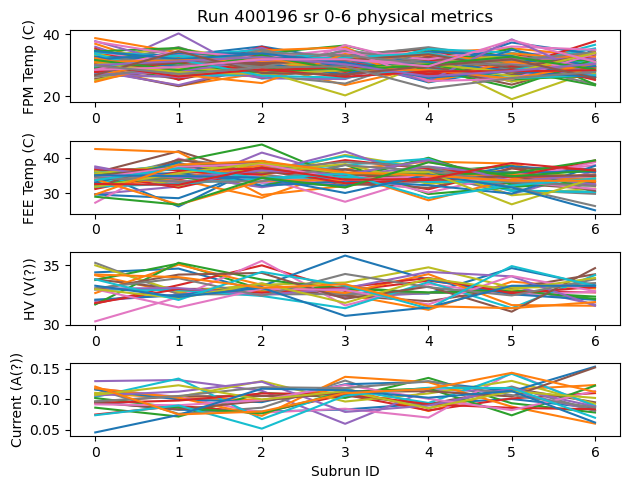

In [9]:
#OTHER METRICS FUNCTION TEST
physical_summary(400196,6)

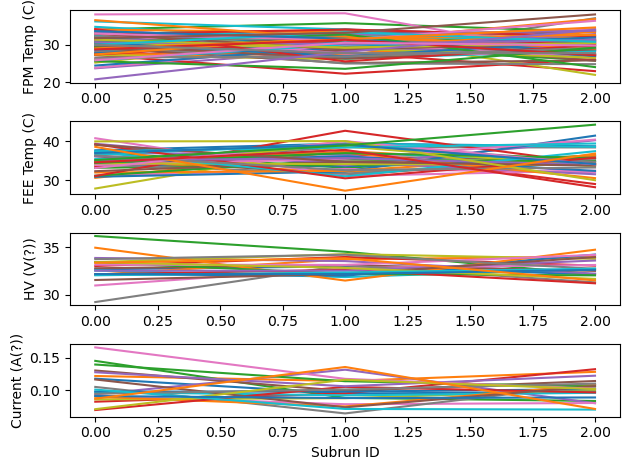

In [8]:
#OTHER METRICS WORKING CELL

run=400196
subruns=3 #line that will eventually change with some stuff
modules=22

fpmTemp_list=[]
feeTemp_list=[]
hv_list=[]
current_list=[]

for sr in range(subruns):

   fpmTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FPMs_run{run}_subrun{sr}.npy')
   fpmTemp_list.append(fpmTemp_data)

   feeTemp_data=np.load(f'/data/user/fbivens5020/mock_data/temperatures_FEEs_run{run}_subrun{sr}.npy')
   feeTemp_list.append(feeTemp_data)

   hv_data=np.load(f'/data/user/fbivens5020/mock_data/HV_FPMs_run{run}_subrun{sr}.npy')
   hv_list.append(hv_data)

   current_data=np.load(f'/data/user/fbivens5020/mock_data/Current_FEEs_run{run}_subrun{sr}.npy')
   current_list.append(current_data)

fpmTemps=np.zeros((modules*4,3,len(fpmTemp_list[:])))
feeTemps=np.zeros((modules*2,3,len(feeTemp_list[:])))
hv=np.zeros((modules,3,len(hv_list[:])))
current=np.zeros((modules,3,len(current_list[:])))

for sr in range(subruns):

   for quad in range(modules*4):
      fpmTemps[quad][0][sr]=sr
      fpmTemps[quad][1][sr]=fpmTemp_list[sr][quad]
      fpmTemps[quad][2][sr]=quad//4

   for board in range(modules*2):
      feeTemps[board][0][sr]=sr
      feeTemps[board][1][sr]=feeTemp_list[sr][board]
      feeTemps[board][2][sr]=board//2

   for mod in range(modules):
      hv[mod][0][sr]=sr
      hv[mod][1][sr]=hv_list[sr][mod]
      hv[mod][2][sr]=mod
      current[mod][0][sr]=sr
      current[mod][1][sr]=current_list[sr][mod]
      current[mod][2][sr]=mod

fig, (ax1,ax2,ax3,ax4)=plt.subplots(4,1)

for quad in range(modules*4):
   ax1.plot(fpmTemps[quad][0], fpmTemps[quad][1])
ax1.set_ylabel("FPM Temp (C)")

for board in range(modules*2):
   ax2.plot(feeTemps[board][0], feeTemps[board][1])
ax2.set_ylabel("FEE Temp (C)")

for mod in range(modules):
   ax3.plot(hv[mod][0],hv[mod][1])
   ax4.plot(current[mod][0],current[mod][1])
ax3.set_ylabel("HV (V(?))")
ax4.set_ylabel("Current (A(?))")
ax4.set_xlabel("Subrun ID")
fig.tight_layout()
plt.show()




[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun6_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun6.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun6_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 3269
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Numb

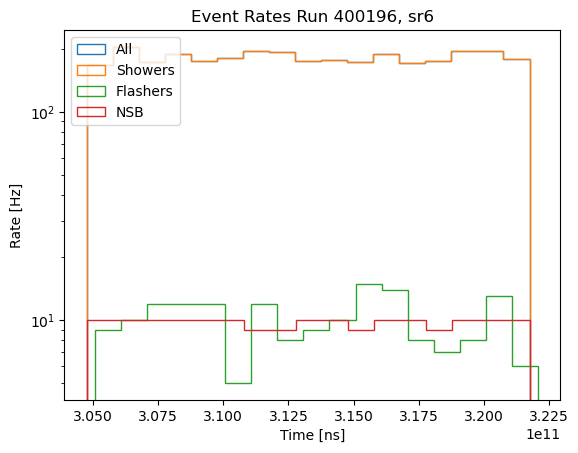

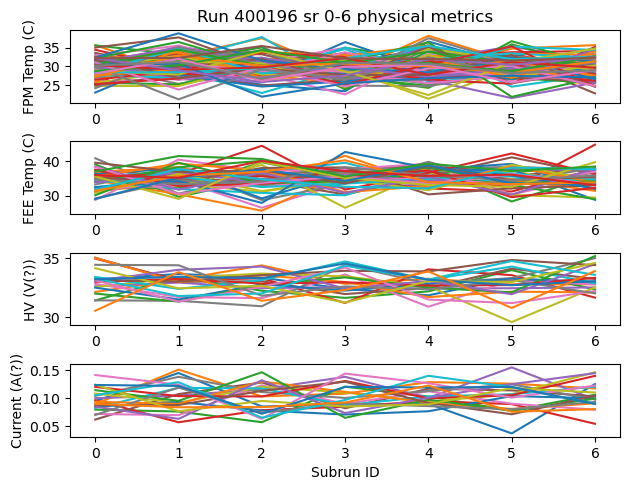

Run 400196 sr6 summary


In [ ]:
#CONDENSED FUNCTION CELL (no

def sr_summary(run_id, sr_number, test=False, resolution=1, modules=22):

    event_rate_summary(run_id, sr_number, test=test, resolution=resolution)

    physical_summary(run_id, sr_number, modules=modules)

    print(f"Run {run_id} sr{sr_number} summary")

sr_summary(400196, 6)
    

In [4]:
#CONDENSED FUNCTION TESTING (Possibly broken?)



#imagine some function finds the newest run file and spits out
newest_sr=2
run=400196
for sr in range(newest_sr):
    sr_summary(run, sr)
print("done")

NameError: name 'sr_summary' is not defined

In [3]:
#NEWEST FILE DETECTOR function (run on startup)

def get_new_sr(run_base=400195, subrun_base=0):

   run=None
   while run==None:
      if os.path.exists(f"/data/user/fbivens5020/mock_data/Current_FEEs_run{run_base+1}_subrun0.npy")==True:
         run_base=run_base+1
      else:
         run=run_base

   subrun=None
   while subrun==None:
      if os.path.exists(f"/data/user/fbivens5020/mock_data/Current_FEEs_run{run}_subrun{subrun_base+1}.npy")==True:
         subrun_base=subrun_base+1
      else:
         subrun=subrun_base
   return run, subrun

get_new_sr(run_base=400215)

(400215, 15)

Latest Subrun: Run 400196 sr15
[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400196_subrun15_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400196_subrun15.r1
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400196_subrun15_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 3318
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TMPIX in Ped File: 64
Mon Jun 

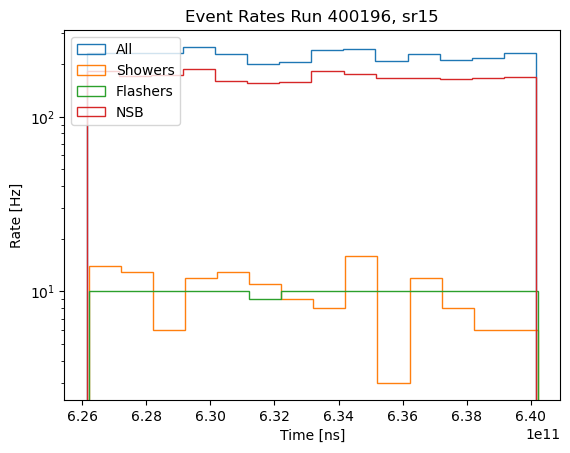

EventFile::Close()
EventFile::Close()
EventFile::Close()
EventFile::Close()


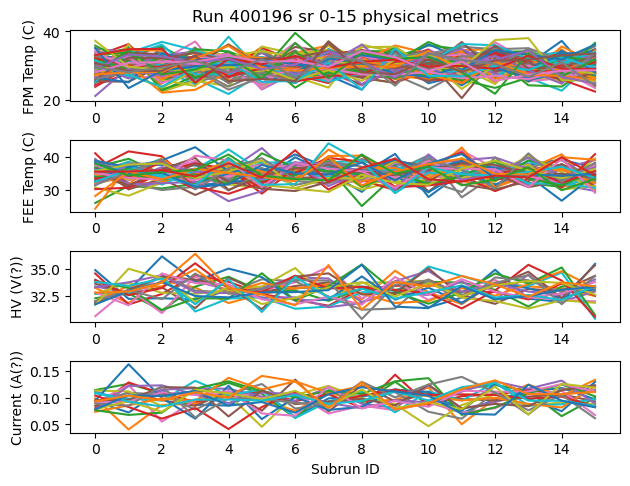

Run 400196 sr15 summary


KeyboardInterrupt: 

In [ ]:
#final loop that actually runs the stuff (do not )
#works fine but shouldn't stop till its spit out 30 graphs and I haven't tested the stopping function
active=False

while active==True:
   current_sr=get_new_sr()
   print(f"Latest Subrun: Run {current_sr[0]} sr{current_sr[1]}")
   sr_summary(current_sr[0],current_sr[1])
   next_sr=get_new_sr()
   while current_sr==next_sr:
      next_sr=get_new_sr()
      if current_sr[1]==15:
         active=False
         break

In [4]:
def real_new_sort(sr_data,subrun, sorted_run_data, cuts):
   confirmations=[[],[],[],[],0]
   sorted_subrun=[[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]]]
   for ev in range(len(sr_data[0])):
        #all events data
        sorted_run_data[0][0].append(sr_data[5][ev]) #event time
        sorted_run_data[0][1].append(sr_data[3][ev]) #mean charge
        sorted_run_data[0][2].append(sr_data[4][ev]) #charge std
        sorted_run_data[0][3].append(sr_data[1][ev]) #mean time
        sorted_run_data[0][4].append(sr_data[2][ev]) #time std
        sorted_run_data[0][5].append(ev)#event id inside subrun
        sorted_run_data[0][6].append(subrun)# subrun id to make event id usable
        #again but for the subrun only
        sorted_subrun[0][0].append(sr_data[5][ev]) #event time
        sorted_subrun[0][1].append(sr_data[3][ev]) #mean charge
        sorted_subrun[0][2].append(sr_data[4][ev]) #charge std
        sorted_subrun[0][3].append(sr_data[1][ev]) #mean time
        sorted_subrun[0][4].append(sr_data[2][ev]) #time std
        sorted_subrun[0][5].append(ev)#event id inside subrun
        sorted_subrun[0][6].append(subrun)# subrun id to make event id usable

        if ev==0:
            sorted_run_data[0][7].append(0)
            sorted_subrun[0][7].append(0)
            subruns.append([subrun, sr_data[5][ev]]) #if first event delta t =0, also record the subrun start time
        else:
            sorted_run_data[0][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
            sorted_subrun[0][7].append(sr_data[5][ev]-sr_data[5][ev-1])

        if sr_data[3][ev]>cuts[1] and sr_data[3][ev]<cuts[0] and sr_data[4][ev]>cuts[3] and sr_data[4][ev]<cuts[2]:
            #charge showers
            confirmations[0].append(ev)
            sorted_run_data[4][0].append(sr_data[5][ev]) #event time
            sorted_run_data[4][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[4][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[4][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[4][4].append(sr_data[2][ev]) #time std
            sorted_run_data[4][5].append(ev)#event id inside subrun
            sorted_run_data[4][6].append(subrun)# subrun id to make event id usable
            #again but for the subrun only
            sorted_subrun[4][0].append(sr_data[5][ev]) #event time
            sorted_subrun[4][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[4][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[4][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[4][4].append(sr_data[2][ev]) #time std
            sorted_subrun[4][5].append(ev)#event id inside subrun
            sorted_subrun[4][6].append(subrun)# subrun id to make event id usable
            
            if ev==0:
                sorted_run_data[4][7].append(0)
                sorted_subrun[4][7].append(0)
                 #if first event delta t=0
            else:
                sorted_run_data[4][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[4][7].append(sr_data[5][ev]-sr_data[5][ev-1])
          
        elif sr_data[3][ev]>cuts[5] and sr_data[3][ev]<cuts[4]:
            #actually just flashers now
            sorted_run_data[2][0].append(sr_data[5][ev]) #event time
            sorted_run_data[2][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[2][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[2][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[2][4].append(sr_data[2][ev]) #time std
            sorted_run_data[2][5].append(ev)#event id inside subrun
            sorted_run_data[2][6].append(subrun)# subrun id to make event id usable

            #again but for the subrun only
            sorted_subrun[2][0].append(sr_data[5][ev]) #event time
            sorted_subrun[2][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[2][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[2][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[2][4].append(sr_data[2][ev]) #time std
            sorted_subrun[2][5].append(ev)#event id inside subrun
            sorted_subrun[2][6].append(subrun)# subrun id to make event id usable
            if ev==0:
                sorted_run_data[2][7].append(0)
                sorted_subrun[2][7].append(0)
                 #if first event delta t=0
            else:
                sorted_run_data[2][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[2][7].append(sr_data[5][ev]-sr_data[5][ev-1])
        else:
            #charge noise i guess we're still doing this
            confirmations[1].append(ev)
            sorted_run_data[6][0].append(sr_data[5][ev]) #event time
            sorted_run_data[6][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[6][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[6][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[6][4].append(sr_data[2][ev]) #time std
            sorted_run_data[6][5].append(ev)#event id inside subrun
            sorted_run_data[6][6].append(subrun)# subrun id to make event id usable

            #again but for the subrun only
            sorted_subrun[6][0].append(sr_data[5][ev]) #event time
            sorted_subrun[6][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[6][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[6][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[6][4].append(sr_data[2][ev]) #time std
            sorted_subrun[6][5].append(ev)#event id inside subrun
            sorted_subrun[6][6].append(subrun)# subrun id to make event id usable
            if ev==0:
                sorted_run_data[6][7].append(0)
                sorted_subrun[6][7].append(0)
                 #if first event delta t=0
            else:
                sorted_run_data[6][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[6][7].append(sr_data[5][ev]-sr_data[5][ev-1])

        if sr_data[3][ev]>cuts[9] and sr_data[3][ev]<cuts[8] and sr_data[2][ev]>cuts[11] and sr_data[2][ev]<cuts[10]:
            #time showers
            confirmations[2].append(ev)
            sorted_run_data[5][0].append(sr_data[5][ev]) #event time
            sorted_run_data[5][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[5][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[5][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[5][4].append(sr_data[2][ev]) #time std
            sorted_run_data[5][5].append(ev)#event id inside subrun
            sorted_run_data[5][6].append(subrun)# subrun id to make event id usable

            #again but for the subrun only
            sorted_subrun[5][0].append(sr_data[5][ev]) #event time
            sorted_subrun[5][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[5][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[5][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[5][4].append(sr_data[2][ev]) #time std
            sorted_subrun[5][5].append(ev)#event id inside subrun
            sorted_subrun[5][6].append(subrun)# subrun id to make event id usable
            if ev==0:
                sorted_run_data[5][7].append(0)
                sorted_subrun[5][7].append(0)
                 #if first event delta t=0
            else:
                sorted_run_data[5][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[5][7].append(sr_data[5][ev]-sr_data[5][ev-1])

        elif sr_data[3][ev]>cuts[5] and sr_data[3][ev]<cuts[4]:
            #don't gotta do anything :)
            confirmations[4]+=1
        else: 
            #time noise
            confirmations[3].append(ev)
            sorted_run_data[7][0].append(sr_data[5][ev]) #event time
            sorted_run_data[7][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[7][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[7][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[7][4].append(sr_data[2][ev]) #time std
            sorted_run_data[7][5].append(ev)#event id inside subrun
            sorted_run_data[7][6].append(subrun)# subrun id to make event id usable

            #again but for the subrun only
            sorted_subrun[7][0].append(sr_data[5][ev]) #event time
            sorted_subrun[7][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[7][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[7][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[7][4].append(sr_data[2][ev]) #time std
            sorted_subrun[7][5].append(ev)#event id inside subrun
            sorted_subrun[7][6].append(subrun)# subrun id to make event id usable
            if ev==0:
                sorted_run_data[7][7].append(0)
                sorted_subrun[7][7].append(0)
                #if first event delta t=0
            else:
                sorted_run_data[7][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[7][7].append(sr_data[5][ev]-sr_data[5][ev-1])

        if ev in confirmations[0] and confirmations[2]:
            #confirmed showers
            sorted_run_data[1][0].append(sr_data[5][ev]) #event time
            sorted_run_data[1][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[1][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[1][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[1][4].append(sr_data[2][ev]) #time std
            sorted_run_data[1][5].append(ev)#event id inside subrun
            sorted_run_data[1][6].append(subrun)# subrun id to make event id usable

            #again but for the subrun only
            sorted_subrun[1][0].append(sr_data[5][ev]) #event time
            sorted_subrun[1][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[1][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[1][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[1][4].append(sr_data[2][ev]) #time std
            sorted_subrun[1][5].append(ev)#event id inside subrun
            sorted_subrun[1][6].append(subrun)# subrun id to make event id usable
            if ev==0:
                sorted_run_data[1][7].append(0)
                sorted_subrun[1][7].append(0)
                #if first event delta t=0
            else:
                sorted_run_data[1][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[1][7].append(sr_data[5][ev]-sr_data[5][ev-1])
        
        if ev in confirmations[1] and confirmations[3]:
            #confirmed noise
            sorted_run_data[3][0].append(sr_data[5][ev]) #event time
            sorted_run_data[3][1].append(sr_data[3][ev]) #mean charge
            sorted_run_data[3][2].append(sr_data[4][ev]) #charge std
            sorted_run_data[3][3].append(sr_data[1][ev]) #mean time
            sorted_run_data[3][4].append(sr_data[2][ev]) #time std
            sorted_run_data[3][5].append(ev)#event id inside subrun
            sorted_run_data[3][6].append(subrun)# subrun id to make event id usable

            #again but for the subrun only
            sorted_subrun[3][0].append(sr_data[5][ev]) #event time
            sorted_subrun[3][1].append(sr_data[3][ev]) #mean charge
            sorted_subrun[3][2].append(sr_data[4][ev]) #charge std
            sorted_subrun[3][3].append(sr_data[1][ev]) #mean time
            sorted_subrun[3][4].append(sr_data[2][ev]) #time std
            sorted_subrun[3][5].append(ev)#event id inside subrun
            sorted_subrun[3][6].append(subrun)# subrun id to make event id usable
            if ev==0:
                sorted_run_data[3][7].append(0)
                sorted_subrun[3][7].append(0)
                #if first event delta t=0
            else:
                sorted_run_data[3][7].append(sr_data[5][ev]-sr_data[5][ev-1]) #delta t
                sorted_subrun[3][7].append(sr_data[5][ev]-sr_data[5][ev-1])

   return sorted_run_data, sorted_subrun

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400215_subrun0_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400215_subrun0.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400215_subrun0_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 18751
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Num

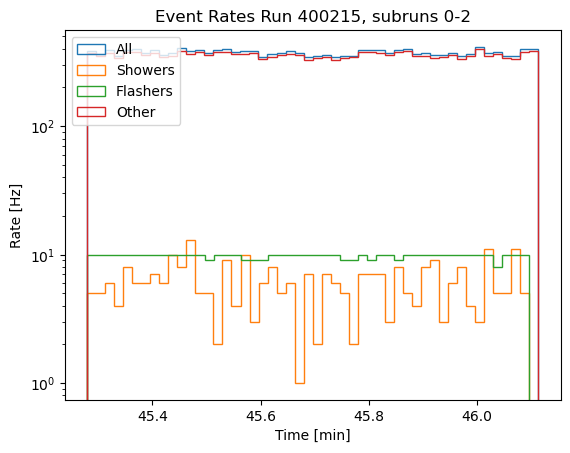

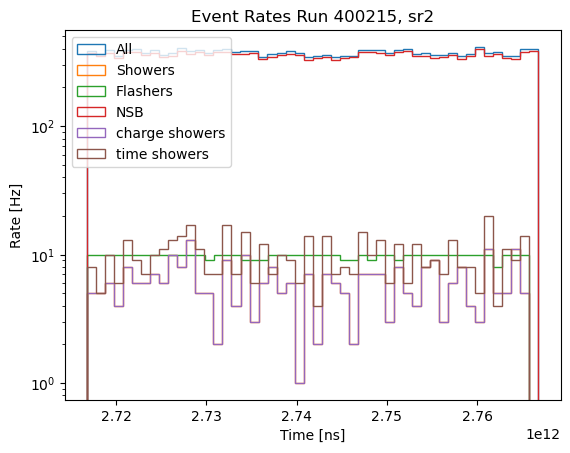

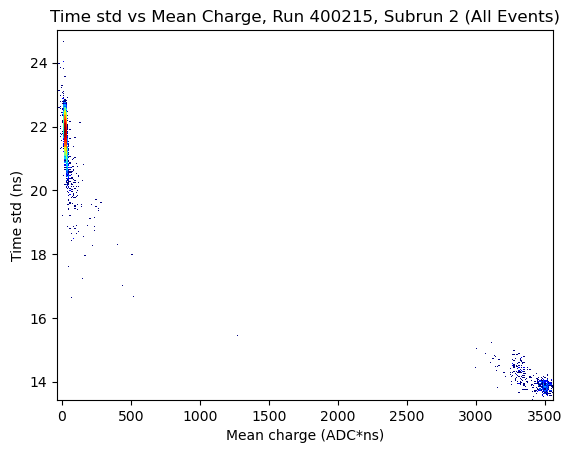

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400215_subrun1_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400215_subrun1.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400215_subrun1_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 19265
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Num

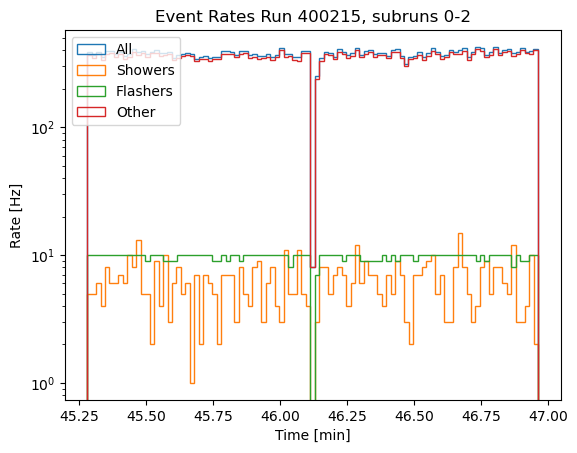

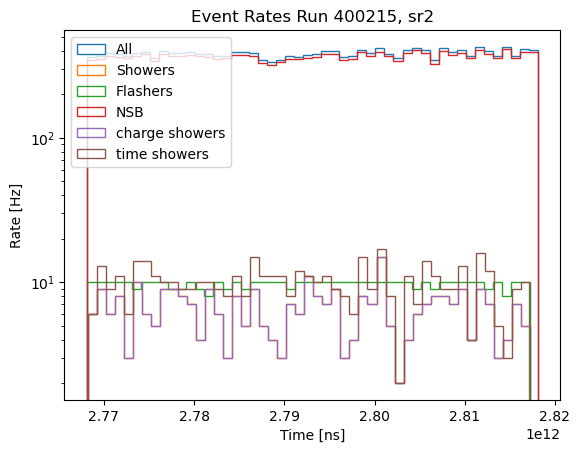

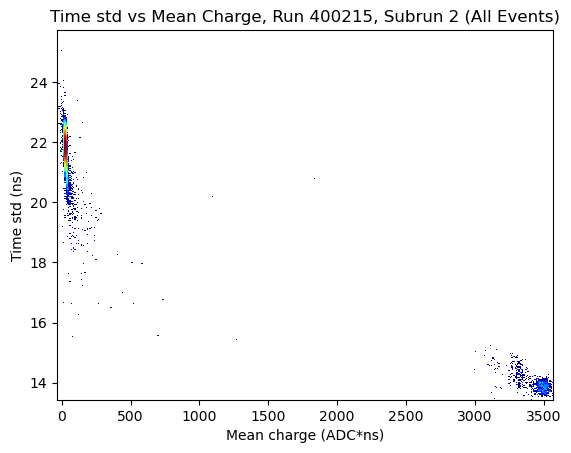

[main] Calibrating file 1/1
[main] Input file: /data/user/fbivens5020/mock_data/run400215_subrun2_r0.tio
[main] Output file: /data/user/fbivens5020/mock_data/run400215_subrun2.r1
[main] WARNING: calibrated data file already exists, deleting file...
[CalibrationApplier] Opening R0 Event File: /data/user/fbivens5020/mock_data/run400215_subrun2_r0.tio
[CalibrationApplier] EVENT FILE CONTENTS: 
	 NModules: 24
	 ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 
	 NCells: 16384
	 NBlockSamples: 32
	 NBlocks: 512
	 NEvents: 20201
	 NSamples: 64
	 SkipSamples: 0
[CalibrationApplier] Creating R1 Writer
[CalibratorConstructor] Creating Calibrator
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Loading pedestal file: /data/wipac/CTA/targetcdata/run400032_pedestal.tcal
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Number of TM in Ped File: 24
Mon Jun  1 14:10:38 2026 [CTA::TargetCalib::Calibrator::LoadPed] DEBUG :Num

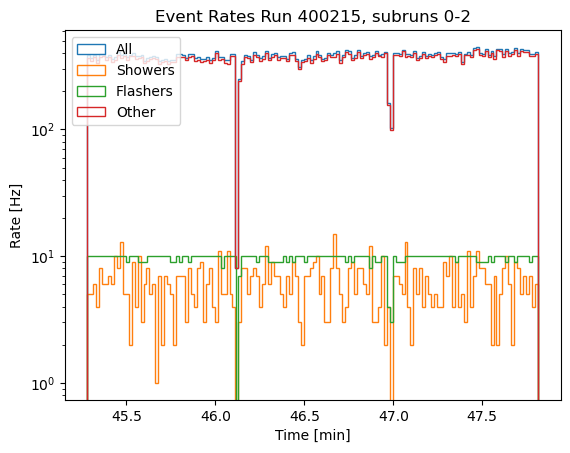

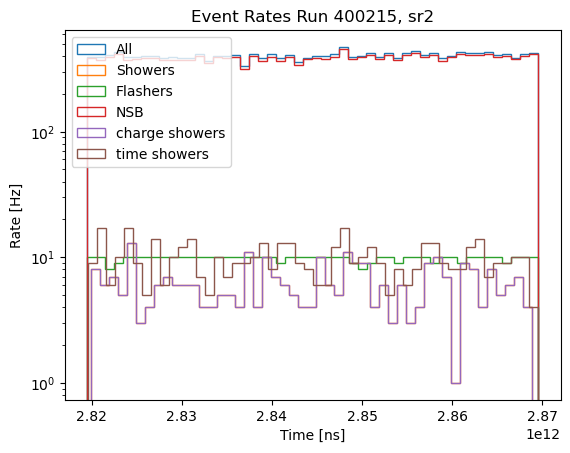

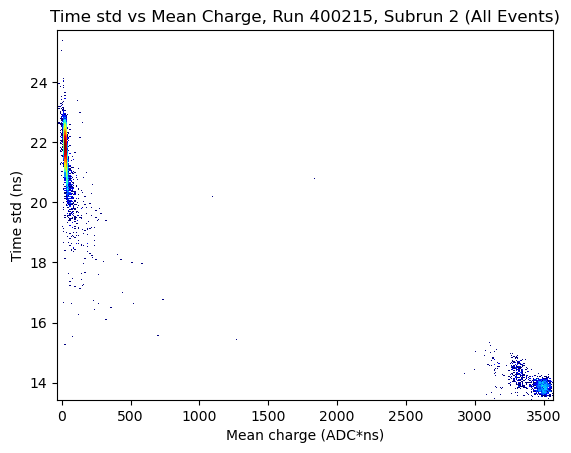

In [5]:
#Working cell for overall event rate graph 
#you only have to run this one once for a stupid long time to test plotting stuff, unless you crash the kernel

subrun_number=3
run_id=400215
run_data=[]
sorted_run_data=[[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]],[[],[],[],[],[],[],[],[]]]
runs=[]
subruns=[]
type_number=10
block=False
# types_list=[all_events_list,conf_shower_list,conf_flasher_list,conf_noise_list,charge_shower_list,time_shower_list,charge_flasher_list,time_flasher_list,charge_noise_list,time_noise_list]

for subrun in range(subrun_number):
    r0_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(subrun)+'_r0.tio'

    tcal_file='/data/wipac/CTA/targetcdata/run400032_pedestal.tcal'

    r1_file='/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(subrun)+'.r1'
    reader=get_reader(r0_file, tcal_file, r1_file)
    sr_data=collect_stats(reader)
    run_data.append(sr_data)
    cuts=get_cuts()

    sort=real_new_sort(sr_data,subrun, sorted_run_data, cuts)

    sorted_run_data=sort[0]
    sorted_subrun=sort[1]
    sorted_run_array=[]
    for type in range(8):
        sorted_run_array.append(np.array(sorted_run_data[type]))
    sorted_subrun_array=[]
    for type in range(8):
        sorted_subrun_array.append(np.array(sorted_subrun[type]))

    modifier=1
    time_step = 60E9
    extra_lines=False
    boxes=True

    fig, ax = plt.subplots()

    ax.hist(sorted_run_array[0][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[0][0]))], bins = np.arange(sorted_run_array[0][0][0]/(time_step), sorted_run_array[0][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'All') 
    ax.hist(sorted_run_array[1][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[1][0]))], bins = np.arange(sorted_run_array[1][0][0]/(time_step), sorted_run_array[1][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Showers') 
    ax.hist(sorted_run_array[2][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[2][0]))], bins = np.arange(sorted_run_array[2][0][0]/(time_step), sorted_run_array[2][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Flashers') 
    ax.hist(sorted_run_array[3][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[3][0]))], bins = np.arange(sorted_run_array[3][0][0]/(time_step), sorted_run_array[3][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Other') 
            
    if extra_lines==True:
        ax.hist(sorted_run_array[4][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[4][0]))], bins = np.arange(sorted_run_array[4][0][0]/(time_step), sorted_run_array[4][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Charge Showers') 
        ax.hist(sorted_run_array[5][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[5][0]))], bins = np.arange(sorted_run_array[5][0][0]/(time_step), sorted_run_array[5][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Time Showers') 

    ax.legend(loc='upper left')
    ax.set_title(f"Event Rates Run {run_id}, subruns 0-{subrun_number-1}")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Rate [Hz]")
    plt.show()


    fig, ax = plt.subplots()
    ax.hist(sorted_subrun_array[0][0], weights = [modifier for _ in range(len(sorted_subrun_array[0][0]))], bins = np.arange(sorted_subrun_array[0][0][0], sorted_subrun_array[0][0][-1], 1E9/modifier), log=True, histtype = 'step', label = 'All') 
    ax.hist(sorted_subrun_array[1][0], weights = [modifier for _ in range(len(sorted_subrun_array[1][0]))], bins = np.arange(sorted_subrun_array[1][0][0], sorted_subrun_array[1][0][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Showers') 
    ax.hist(sorted_subrun_array[2][0], weights = [modifier for _ in range(len(sorted_subrun_array[2][0]))], bins = np.arange(sorted_subrun_array[2][0][0], sorted_subrun_array[2][0][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Flashers') 
    ax.hist(sorted_subrun_array[3][0], weights = [modifier for _ in range(len(sorted_subrun_array[3][0]))], bins = np.arange(sorted_subrun_array[3][0][0], sorted_subrun_array[3][0][-1], 1E9/modifier), log=True, histtype = 'step', label = 'NSB') 
        

    ax.hist(sorted_subrun_array[4][0], weights = [modifier for _ in range(len(sorted_subrun_array[4][0]))], bins = np.arange(sorted_subrun_array[4][0][0], sorted_subrun_array[4][0][-1], 1E9/modifier), log=True, histtype = 'step', label = 'charge showers') 
    ax.hist(sorted_subrun_array[5][0], weights = [modifier for _ in range(len(sorted_subrun_array[5][0]))], bins = np.arange(sorted_subrun_array[5][0][0], sorted_subrun_array[5][0][-1], 1E9/modifier), log=True, histtype = 'step', label = 'time showers') 
    
    ax.legend(loc='upper left')
    ax.set_title(f"Event Rates Run {run_id}, sr{subrun_number-1}")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Rate [Hz]")
    plt.show()



    fig=plt.figure()
    ax=fig.add_subplot(111)
    ax.hist2d(sorted_run_array[0][1], sorted_run_array[0][4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

    if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[1],cuts[3]), width=(cuts[0]-cuts[1]), height=(cuts[2]-cuts[3]), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[5],cuts[7]), width=(cuts[4]-cuts[5]), height=(cuts[6]-cuts[7]), linewidth=1, color='red', fill=False))

    ax.set_title(f"Time std vs Mean Charge, Run {run_id}, Subrun {subrun_number-1} (All Events)")
    ax.set_xlabel("Mean charge (ADC*ns)")
    ax.set_ylabel("Time std (ns)")
    plt.show()
                
# #broken block test i refuse to get rid of for unknown reasons
# if block==True:
#     print('block is true')
#     # no_conf_showers=0
#     # no_total_events=0
#     # no_conf_flashers=0
#     # no_charge_showers=0
#     # no_time_showers=0
#     # no_charge_flashers=0
#     # no_time_flashers=0

#     # for sr in range(subrun+1):
#     # no_conf_showers=no_conf_showers+len(run_data_sorted[sr][1][1])
#     # no_total_events=no_total_events+len(run_data_sorted[sr][0][1])
#     # no_conf_flashers=no_conf_flashers+len(run_data_sorted[sr][2][1])
#     # no_charge_showers=no_charge_showers+len(run_data_sorted[sr][4][1])
#     # no_time_showers=no_time_showers+len(run_data_sorted[sr][5][1])
#     # no_charge_flashers=no_charge_flashers+len(run_data_sorted[sr][6][1])
#     # no_time_flashers=no_time_flashers+len(run_data_sorted[sr][7][1])

#     # print(f"\nsubruns 0-{subrun} have {no_conf_showers} confirmed showers, {no_total_events} total events, and {no_conf_flashers} confimed flashers\n")
#     # print(f"Also they have {no_charge_showers} charge showers, {no_time_showers} time showers, {no_charge_flashers} charge flashers, and {no_time_flashers} time flashers\n")
#     # #end of important confirmation block
# # print(f'according to new list, there are {len(all_events_list)} events, {len(conf_shower_list)} confirmed showers, and {len(conf_flasher_list)} flashers')



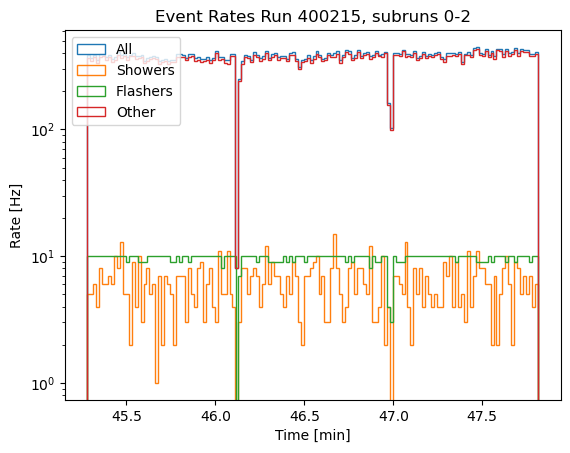

ValueError: negative dimensions are not allowed

In [6]:
#another histogram cell, only works with the last subrun called by the for loop cell
sorted_run_array=[]
for type in range(8):
      sorted_run_array.append(np.array(sorted_run_data[type]))

modifier=1
time_step = 60E9
extra_lines=False
boxes=True

fig, ax = plt.subplots()

ax.hist(sorted_run_array[0][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[0][0]))], bins = np.arange(sorted_run_array[0][0][0]/(time_step), sorted_run_array[0][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'All') 
ax.hist(sorted_run_array[1][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[1][0]))], bins = np.arange(sorted_run_array[1][0][0]/(time_step), sorted_run_array[1][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Showers') 
ax.hist(sorted_run_array[2][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[2][0]))], bins = np.arange(sorted_run_array[2][0][0]/(time_step), sorted_run_array[2][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Flashers') 
ax.hist(sorted_run_array[3][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[3][0]))], bins = np.arange(sorted_run_array[3][0][0]/(time_step), sorted_run_array[3][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Other') 
        
if extra_lines==True:
    ax.hist(sorted_run_array[4][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[4][0]))], bins = np.arange(sorted_run_array[4][0][0]/(time_step), sorted_run_array[4][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Charge Showers') 
    ax.hist(sorted_run_array[5][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[5][0]))], bins = np.arange(sorted_run_array[5][0][0]/(time_step), sorted_run_array[5][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Time Showers') 

ax.legend(loc='upper left')
ax.set_title(f"Event Rates Run {run_id}, subruns 0-{subrun_number-1}")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Rate [Hz]")
plt.show()


# fig, ax = plt.subplots()
ax.hist(sr_data[5], weights = [modifier for _ in range(len(sr_data[5]))], bins = np.arange(sr_data[5][0], sr_data[5][-1], 1E9/modifier), log=True, histtype = 'step', label = 'All') 
ax.hist(sorted_subrun[1][1], weights = [modifier for _ in range(len(sorted_subrun[1][1]))], bins = np.arange(sorted_subrun[1][1][0], sorted_subrun[1][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Showers') 
ax.hist(sorted_subrun[2][1], weights = [modifier for _ in range(len(sorted_subrun[2][1]))], bins = np.arange(sorted_subrun[2][1][0], sorted_subrun[2][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'Flashers') 
ax.hist(sorted_subrun[3][1], weights = [modifier for _ in range(len(sorted_subrun[3][1]))], bins = np.arange(sorted_subrun[3][1][0], sorted_subrun[3][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'NSB') 
    

ax.hist(sorted_subrun[4][1], weights = [modifier for _ in range(len(sorted_subrun[4][1]))], bins = np.arange(sorted_subrun[4][1][0], sorted_subrun[4][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'charge showers') 
ax.hist(sorted_subrun[5][1], weights = [modifier for _ in range(len(sorted_subrun[5][1]))], bins = np.arange(sorted_subrun[5][1][0], sorted_subrun[5][1][-1], 1E9/modifier), log=True, histtype = 'step', label = 'time showers') 
   
ax.legend(loc='upper left')
ax.set_title(f"Event Rates Run {run_id}, sr{subrun_number-1}")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Rate [Hz]")
plt.show()



fig=plt.figure()
ax=fig.add_subplot(111)
ax.hist2d(sorted_run_array[0][1], sorted_run_array[0][4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

if boxes==True:
        ax.add_patch(patches.Rectangle(xy=(cuts[1],cuts[3]), width=(cuts[0]-cuts[1]), height=(cuts[2]-cuts[3]), linewidth=1, color='green', fill=False))
        ax.add_patch(patches.Rectangle(xy=(cuts[5],cuts[7]), width=(cuts[4]-cuts[5]), height=(cuts[6]-cuts[7]), linewidth=1, color='red', fill=False))

ax.set_title(f"Time std vs Mean Charge, Run {run_id}, Subrun {subrun_number-1} (All Events)")
ax.set_xlabel("Mean charge (ADC*ns)")
ax.set_ylabel("Time std (ns)")
plt.show()


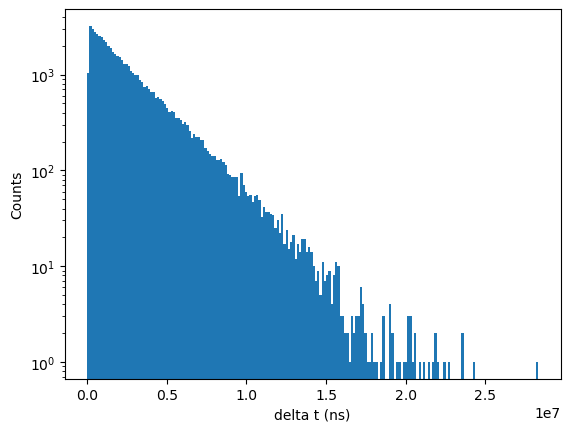

In [ ]:
#time dt graph
fig=plt.figure()
ax=fig.add_subplot(111)
ax.hist(sorted_run_data[0][7], bins = 200, log=True)
ax.set_xlabel("delta t (ns)")
ax.set_ylabel("Counts")
plt.show()

In [65]:
sorted_run_data[0][1]/(60E9)

array([2.14220433, 2.14238159, 2.14243463, ..., 4.37574092, 4.37575039,
       4.37582638], shape=(24187,))

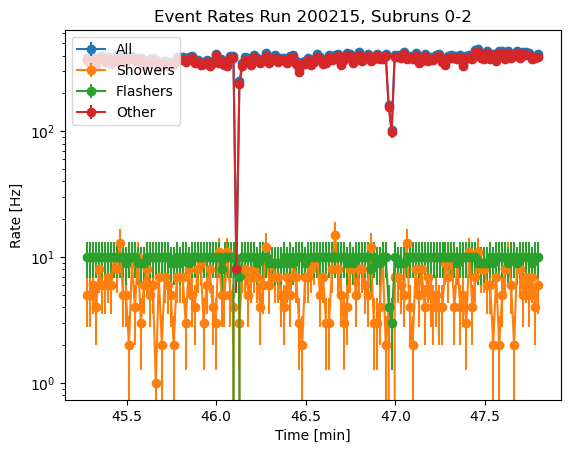

In [36]:

all_hist=np.histogram(sorted_run_array[0][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[0][0]))], bins = np.arange(sorted_run_data[0][0][0]/(time_step), sorted_run_data[0][0][-1]/(time_step), (1E9/time_step)/modifier))
show_hist=np.histogram(sorted_run_array[1][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[1][0]))], bins = np.arange(sorted_run_array[1][0][0]/(time_step), sorted_run_array[1][0][-1]/(time_step), (1E9/time_step)/modifier))
flash_hist=np.histogram(sorted_run_array[2][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[2][0]))], bins = np.arange(sorted_run_array[2][0][0]/(time_step), sorted_run_array[2][0][-1]/(time_step), (1E9/time_step)/modifier))
other_hist=np.histogram(sorted_run_array[3][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[3][0]))], bins = np.arange(sorted_run_array[3][0][0]/(time_step), sorted_run_array[3][0][-1]/(time_step), (1E9/time_step)/modifier))
# print(all_hist)
# print(show_hist, flash_hist, other_hist)

fig,ax=plt.subplots()
ax.errorbar(all_hist[1][:-1],all_hist[0],yerr=np.sqrt(all_hist[0]),fmt='o-', label = 'All')
ax.errorbar(show_hist[1][:-1],show_hist[0],yerr=np.sqrt(show_hist[0]),fmt='o-', label = 'Showers')
ax.errorbar(flash_hist[1][:-1],flash_hist[0],yerr=np.sqrt(flash_hist[0]),fmt='o-', label = 'Flashers')
ax.errorbar(other_hist[1][:-1],other_hist[0],yerr=np.sqrt(other_hist[0]),fmt='o-', label = 'Other')
ax.legend(loc='upper left')
ax.set_title(f"Event Rates Run 200215, Subruns 0-2")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Rate [Hz]")
ax.set_yscale('log')
#  fig.savefig(f"{display_plots_path}Event_Rate_Histogram.jpg")
#  fig.savefig(f"{plots_save_location}Run_{current_sr[0]}_Event_Rate_Histogram.jpg")
plt.show()

# fig, ax = plt.subplots()
# ax.plot(hist_data, log=True, label='All')
# ax.plot(np.histogram(sorted_run_array[1][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[1][0]))], bins = np.arange(sorted_run_array[1][0][0]/(time_step), sorted_run_array[1][0][-1]/(time_step), (1E9/time_step)/modifier)), log=True, label = 'Showers') 
# ax.plot(np.histogram(sorted_run_array[2][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[2][0]))], bins = np.arange(sorted_run_array[2][0][0]/(time_step), sorted_run_array[2][0][-1]/(time_step), (1E9/time_step)/modifier)), log=True, label = 'Flashers') 
# ax.plot(np.histogram(sorted_run_array[3][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_array[3][0]))], bins = np.arange(sorted_run_array[3][0][0]/(time_step), sorted_run_array[3][0][-1]/(time_step), (1E9/time_step)/modifier)), log=True, label = 'Other') 
    


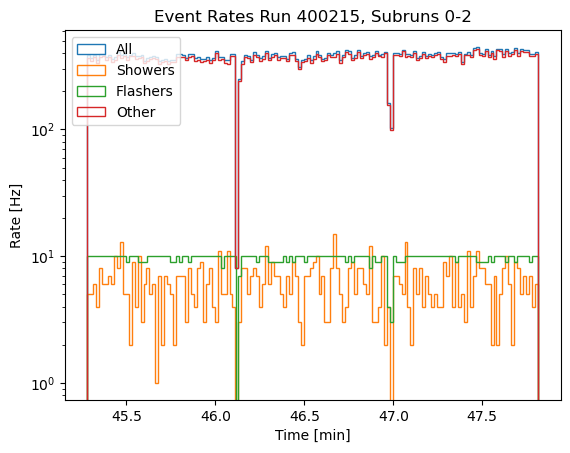

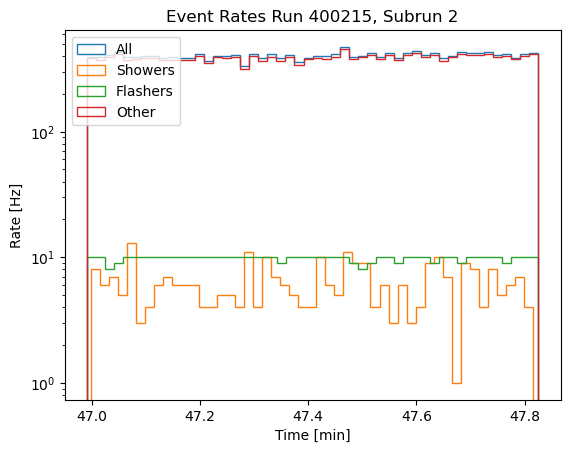

In [15]:
#New event rate histogram function

def event_rate_hists(current_sr, sorted_run_data, sorted_subrun, resolution, time_step, display_plots_path, plots_save_location, extra_lines=False):
    modifier=resolution
    fig, ax = plt.subplots()

    ax.hist(sorted_run_data[0][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[0][0]))], bins = np.arange(sorted_run_data[0][0][0]/(time_step), sorted_run_data[0][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'All') 
    ax.hist(sorted_run_data[1][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[1][0]))], bins = np.arange(sorted_run_data[1][0][0]/(time_step), sorted_run_data[1][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Showers') 
    ax.hist(sorted_run_data[2][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[2][0]))], bins = np.arange(sorted_run_data[2][0][0]/(time_step), sorted_run_data[2][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Flashers') 
    ax.hist(sorted_run_data[3][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[3][0]))], bins = np.arange(sorted_run_data[3][0][0]/(time_step), sorted_run_data[3][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Other') 
        
    if extra_lines==True:
       ax.hist(sorted_run_data[4][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[4][0]))], bins = np.arange(sorted_run_data[4][0][0]/(time_step), sorted_run_data[4][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Charge Showers') 
       ax.hist(sorted_run_data[5][0]/(time_step), weights = [modifier for _ in range(len(sorted_run_data[5][0]))], bins = np.arange(sorted_run_data[5][0][0]/(time_step), sorted_run_data[5][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Time Showers') 

    ax.legend(loc='upper left')
    ax.set_title(f"Event Rates Run {current_sr[0]}, Subruns 0-{current_sr[1]}")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Rate [Hz]")
   #  fig.savefig(f"{display_plots_path}Event_Rate_Histogram.jpg")
   #  fig.savefig(f"{plots_save_location}Run_{current_sr[0]}_Event_Rate_Histogram.jpg")
    plt.show()

    fig, ax = plt.subplots()
    ax.hist(sorted_subrun[0][0]/(time_step), weights = [modifier for _ in range(len(sorted_subrun[0][0]))], bins = np.arange(sorted_subrun[0][0][0]/(time_step), sorted_subrun[0][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'All') 
    ax.hist(sorted_subrun[1][0]/(time_step), weights = [modifier for _ in range(len(sorted_subrun[1][0]))], bins = np.arange(sorted_subrun[1][0][0]/(time_step), sorted_subrun[1][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Showers') 
    ax.hist(sorted_subrun[2][0]/(time_step), weights = [modifier for _ in range(len(sorted_subrun[2][0]))], bins = np.arange(sorted_subrun[2][0][0]/(time_step), sorted_subrun[2][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Flashers') 
    ax.hist(sorted_subrun[3][0]/(time_step), weights = [modifier for _ in range(len(sorted_subrun[3][0]))], bins = np.arange(sorted_subrun[3][0][0]/(time_step), sorted_subrun[3][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Other')  
    
    if extra_lines==True:
       ax.hist(sorted_subrun[4][0]/(time_step), weights = [modifier for _ in range(len(sorted_subrun[4][0]))], bins = np.arange(sorted_subrun[4][0][0]/(time_step), sorted_subrun[4][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Charge Showers') 
       ax.hist(sorted_subrun[5][0]/(time_step), weights = [modifier for _ in range(len(sorted_subrun[5][0]))], bins = np.arange(sorted_subrun[5][0][0]/(time_step), sorted_subrun[5][0][-1]/(time_step), (1E9/time_step)/modifier), log=True, histtype = 'step', label = 'Time Showers')  
    
    ax.legend(loc='upper left')
    ax.set_title(f"Event Rates Run {current_sr[0]}, Subrun {current_sr[1]}")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Rate [Hz]")
   #  fig.savefig(f"{plots_save_location}Run_{current_sr[0]}_Subrun_{current_sr[1]}_Event_Rate.jpg")
    plt.show()

event_rate_hists([400215, 2], sorted_run_array, sorted_subrun_array, 1, 60E9,"/data/user/fbivens5020/DQM_Plots/DQM_display_plots/", "/data/user/fbivens5020/DQM_Plots/", extra_lines=False)

In [44]:
def fixed_cuts(): #fixed up cuts function
    charge_mean_flasher_min=2000
    charge_mean_flasher_max=3750

    charge_mean_noise_min=0
    charge_mean_noise_max=38

    charge_mean_shower_min=40
    charge_mean_shower_max=2000

    charge_std_flasher_min=250
    charge_std_flasher_max=2000

    charge_std_noise_min=0
    charge_std_noise_max=42

    charge_std_shower_min=40
    charge_std_shower_max=2500

    time_std_flasher_min=10
    time_std_flasher_max=18.5

    time_std_noise_min=21
    time_std_noise_max=26

    time_std_shower_min=14
    time_std_shower_max=21

   
    
    return charge_mean_flasher_min, charge_mean_flasher_max, charge_mean_noise_min, charge_mean_noise_max, charge_mean_shower_min, charge_mean_shower_max, charge_std_flasher_min, charge_std_flasher_max, charge_std_noise_min, charge_std_noise_max, charge_std_shower_min, charge_std_shower_max, time_std_flasher_min, time_std_flasher_max, time_std_noise_min, time_std_noise_max, time_std_shower_min, time_std_shower_max

In [39]:
#new 2d histograms function
def sorting_hists_2d(cuts, current_sr, sorted_run_data, sorted_subrun, display_plots_path, plots_save_path, subrun_plots=False, boxes=True, regions=True, flashers=True, tight=False, logx = False, logy = False):
   fig=plt.figure()
   ax=fig.add_subplot(111)
   x = sorted_run_data[0][2]
   xlab = ''
   y = sorted_run_data[0][3]
   ylab = ''
   if logx:
      x = np.log10(x)
      # x[np.isnan(x)] = 0.0
      xlab = 'Log '
      # change x values relevant to boxes here
   if logy:
      y = np.log10(y)
      # y[np.isnan(y)] = 0.0
      ylab = 'Log '

      # change y values relevant to boxes here
   
   # ax.hist2d(x[not (np.isnan(x) or np.isnan(y))], y[not (np.isnan(x) or np.isnan(y))], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))
   ax.hist2d(x, y, bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))


   if boxes==True:
       ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[6]), width=(cuts[1]-cuts[0]), height=(cuts[7]-cuts[6]), linewidth=1, color='blue', fill=False))
      #  ax.add_patch(patches.Rectangle(xy=(cuts[2],cuts[8]), width=(cuts[3]-cuts[2]), height=(cuts[9]-cuts[8]), linewidth=1, color='red', fill=False))
       ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[10]), width=(cuts[5]-cuts[4]), height=(cuts[11]-cuts[10]), linewidth=1, color='green', fill=False))
       

   ax.set_title(f"Charge std vs Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (All Events)")
   ax.set_xlabel(f"{xlab}Mean charge (ADC*ns)")
   ax.set_ylabel(f"{ylab}Charge std (ADC*ns)")
   # ax.set_xscale('log')
   # ax.set_yscale('log')
   # fig.savefig(f'{display_plots_path}charge_std_charge_mean_histogram.jpg')
   # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_charge_mean_histogram.jpg')
   plt.show()

   fig=plt.figure()
   ax=fig.add_subplot(111)
   ax.hist2d(sorted_run_data[0][2], sorted_run_data[0][5], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

   if boxes==True:
       ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[12]), width=(cuts[1]-cuts[0]), height=(cuts[13]-cuts[12]), linewidth=1, color='blue', fill=False))
      #  ax.add_patch(patches.Rectangle(xy=(cuts[2],cuts[14]), width=(cuts[3]-cuts[2]), height=(cuts[15]-cuts[14]), linewidth=1, color='red', fill=False))
       ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[16]), width=(cuts[5]-cuts[4]), height=(cuts[17]-cuts[16]), linewidth=1, color='green', fill=False))

   ax.set_title(f"Time std vs Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (All Events)")
   ax.set_xlabel("Mean charge (ADC*ns)")
   ax.set_ylabel("Time std (ns)")
   # fig.savefig(f'{display_plots_path}time_std_charge_mean_histogram.jpg')
   # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_std_charge_mean_histogram.jpg')
   plt.show()

   if regions==True:
      
      if tight==True:
         charge_window=[[0,cuts[3]+100],[0,cuts[9]+100]]
         time_window=[[0, cuts[3]+100],[cuts[14]-3, cuts[14]+5]]
      else:
         charge_window=[[cuts[4]-50, cuts[5]+100],[cuts[10]-50, cuts[11]+100]]
         time_window=[[cuts[4]-50, cuts[5]+100],[cuts[16]-3, cuts[17]+3]]
    
      fig=plt.figure()
      ax=fig.add_subplot(111)
      ax.hist2d(sorted_run_data[0][2], sorted_run_data[0][3], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=charge_window)

      if boxes==True:
         # ax.add_patch(patches.Rectangle(xy=(cuts[2],cuts[8]), width=(cuts[3]-cuts[2]), height=(cuts[9]-cuts[8]), linewidth=1, color='red', fill=False))
         ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[10]), width=(cuts[5]-cuts[4]), height=(cuts[11]-cuts[10]), linewidth=1, color='green', fill=False))

         # ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[9]), width=(cuts[3]-cuts[4]), height=(10), linewidth=1, color='orange', fill=False)) #zone 11
         # ax.add_patch(patches.Rectangle(xy=(cuts[3],cuts[9]), width=(10), height=(10), linewidth=1, color='orange', fill=False)) #zone 12
         # ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[10]), width=(cuts[3]-cuts[4]), height=(cuts[9]-cuts[10]), linewidth=1, color='orange', fill=False)) #zone 13
         # ax.add_patch(patches.Rectangle(xy=(cuts[3],cuts[10]), width=(10), height=(cuts[9]-cuts[10]), linewidth=1, color='orange', fill=False)) #zone 14
         

      ax.set_title(f"Charge std vs Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Shower Region)")
      ax.set_xlabel("Mean charge (ADC*ns)")
      ax.set_ylabel("Charge std (ADC*ns)")
      # fig.savefig(f'{display_plots_path}charge_std_charge_mean_shower_region_histogram.jpg')
      # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_charge_mean_shower_region_histogram.jpg')
      plt.show()

      fig=plt.figure()
      ax=fig.add_subplot(111)
      ax.hist2d(sorted_run_data[0][2], sorted_run_data[0][5], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None), range=time_window)

      if boxes==True:
         # ax.add_patch(patches.Rectangle(xy=(cuts[2],cuts[14]), width=(cuts[3]-cuts[2]), height=(cuts[15]-cuts[14]), linewidth=1, color='red', fill=False))
         ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[16]), width=(cuts[5]-cuts[4]), height=(cuts[17]-cuts[16]), linewidth=1, color='green', fill=False))

         # ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[14]), width=(cuts[3]-cuts[4]), height=(cuts[17]-cuts[14]), linewidth=1, color='orange', fill=False)) #zone 21
         # ax.add_patch(patches.Rectangle(xy=(cuts[3],cuts[14]), width=(10), height=(cuts[17]-cuts[14]), linewidth=1, color='orange', fill=False)) #zone 22
         # ax.add_patch(patches.Rectangle(xy=(cuts[4],(cuts[14]-1)), width=(cuts[3]-cuts[4]), height=(1), linewidth=1, color='orange', fill=False)) #zone 23
         # ax.add_patch(patches.Rectangle(xy=(cuts[3],(cuts[14]-1)), width=(10), height=(cuts[17]-cuts[14]), linewidth=1, color='orange', fill=False)) #zone 24

      ax.set_title(f"Time std vs Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Shower Region)")
      ax.set_xlabel("Mean charge (ADC*ns)")
      ax.set_ylabel("Time std (ns)")
      # fig.savefig(f'{display_plots_path}time_std_charge_mean_shower_region_histogram.jpg')
      # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_std_charge_mean_shower_region_histogram.jpg')
      plt.show()
   
   if flashers==True:

      fig=plt.figure()
      ax=fig.add_subplot(111)
      ax.hist2d(sorted_run_data[0][2], sorted_run_data[0][3], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[2800,3800],[250,1300]])

      if boxes==True:
         ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[6]), width=(cuts[1]-cuts[0]), height=(cuts[7]-cuts[6]), linewidth=1, color='blue', fill=False))

      ax.set_title(f"Charge std vs Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Flasher Region)")
      ax.set_xlabel("Mean charge (ADC*ns)")
      ax.set_ylabel("Charge std (ADC*ns)")
      # fig.savefig(f'{display_plots_path}charge_std_charge_mean_flasher_region_histogram.jpg')
      # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_charge_mean_flasher_region_histogram.jpg')
      plt.show()

      fig=plt.figure()
      ax=fig.add_subplot(111)
      ax.hist2d(sorted_run_data[0][2], sorted_run_data[0][5], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None), range=[[2800,3800],[12,16]])

      if boxes==True:
         ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[12]), width=(cuts[1]-cuts[0]), height=(cuts[13]-cuts[12]), linewidth=1, color='blue', fill=False))

      ax.set_title(f"Time std vs Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Flasher Region)")
      ax.set_xlabel("Mean charge (ADC*ns)")
      ax.set_ylabel("Time std (ns)")
      # fig.savefig(f'{display_plots_path}time_std_charge_mean_flasher_region_histogram.jpg')
      # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_std_charge_mean_flasher_region_histogram.jpg')
      plt.show()

   if subrun_plots==True:
      fig=plt.figure()
      ax=fig.add_subplot(111)
      ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

      if boxes==True:
         ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[2]), width=(cuts[1]-cuts[0]), height=(cuts[3]-cuts[2]), linewidth=1, color='green', fill=False))
         ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[6]), width=(cuts[5]-cuts[4]), height=(cuts[7]-cuts[6]), linewidth=1, color='red', fill=False))

      ax.set_title(f"Charge std vs Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (All Events)")
      ax.set_xlabel("Mean charge (ADC*ns)")
      ax.set_ylabel("Charge std (ADC*ns)")
      fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_std_charge_mean_histogram.jpg')
      plt.show()

      fig=plt.figure()
      ax=fig.add_subplot(111)
      ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None))

      if boxes==True:
         ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[8]), width=(cuts[1]-cuts[0]), height=(cuts[9]-cuts[8]), linewidth=1, color='green', fill=False))
         ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[10]), width=(cuts[5]-cuts[4]), height=(cuts[11]-cuts[10]), linewidth=1, color='red', fill=False))

      ax.set_title(f"Time std vs Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (All Events)")
      ax.set_xlabel("Mean charge (ADC*ns)")
      ax.set_ylabel("Time std (ns)")
      fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_std_charge_mean_histogram.jpg')
      plt.show()

      if regions==True:
      
         if tight==True:
            charge_window=[[0,cuts[0]+100],[0,cuts[2]+100]]
            time_window=[[0, cuts[0]+100],[cuts[9]-3, cuts[9]+5]]
         else:
            charge_window=[[cuts[0]-50, cuts[1]+100],[cuts[2]-50, cuts[3]+100]]
            time_window=[[cuts[0]-50, cuts[1]+100],[cuts[8]-3, cuts[9]+3]]
    
         fig=plt.figure()
         ax=fig.add_subplot(111)
         ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=charge_window)

         if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[2]), width=(cuts[1]-cuts[0]), height=(cuts[3]-cuts[2]), linewidth=1, color='green', fill=False))

         ax.set_title(f"Charge std vs Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (Shower Region)")
         ax.set_xlabel("Mean charge (ADC*ns)")
         ax.set_ylabel("Charge std (ADC*ns)")
         fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_charge_mean_shower_region_histogram.jpg')
         plt.show()

         fig=plt.figure()
         ax=fig.add_subplot(111)
         ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None), range=time_window)

         if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[0],cuts[8]), width=(cuts[1]-cuts[0]), height=(cuts[9]-cuts[8]), linewidth=1, color='green', fill=False))

         ax.set_title(f"Time std vs Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (Shower Region)")
         ax.set_xlabel("Mean charge (ADC*ns)")
         ax.set_ylabel("Time std (ns)")
         fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_std_charge_mean_shower_region_histogram.jpg')
         plt.show()
         
      if flashers==True:

         fig=plt.figure()
         ax=fig.add_subplot(111)
         ax.hist2d(sr_data[3], sr_data[4], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None),range=[[cuts[4]-50,cuts[5]+50],[cuts[6]-50, cuts[7]+50]])

         if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[6]), width=(cuts[5]-cuts[4]), height=(cuts[7]-cuts[6]), linewidth=1, color='red', fill=False))

         ax.set_title(f"Charge std vs Mean Charge, Run {current_sr[0]}, Subruns{current_sr[1]} (Flasher Region)")
         ax.set_xlabel("Mean charge (ADC*ns)")
         ax.set_ylabel("Charge std (ADC*ns)")
         fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_std_charge_mean_flasher_region_histogram.jpg')
         plt.show()

         fig=plt.figure()
         ax=fig.add_subplot(111)
         ax.hist2d(sr_data[3], sr_data[2], bins = 400,cmap=plt.cm.jet ,norm=colors.LogNorm(vmin=1, vmax = None), range=[[cuts[4]-50,cuts[5]+50],[cuts[10]-3,cuts[11]+3]])

         if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[4],cuts[10]), width=(cuts[5]-cuts[4]), height=(cuts[11]-cuts[10]), linewidth=1, color='red', fill=False))

         ax.set_title(f"Time std vs Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (Flasher Region)")
         ax.set_xlabel("Mean charge (ADC*ns)")
         ax.set_ylabel("Time std (ns)")
         fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_std_charge_mean_flasher_region_histogram.jpg')
         plt.show()



In [122]:
cuts=fixed_cuts()
for cut in range(len(cuts)):
    print(f'\n Cuts[{cut}]: {cuts[cut]}')


 Cuts[0]: 2000

 Cuts[1]: 3000

 Cuts[2]: 0

 Cuts[3]: 38

 Cuts[4]: 35

 Cuts[5]: 2000

 Cuts[6]: 1200

 Cuts[7]: 1800

 Cuts[8]: 0

 Cuts[9]: 42

 Cuts[10]: 30

 Cuts[11]: 2500

 Cuts[12]: 14

 Cuts[13]: 18.5

 Cuts[14]: 21

 Cuts[15]: 26

 Cuts[16]: 14

 Cuts[17]: 22


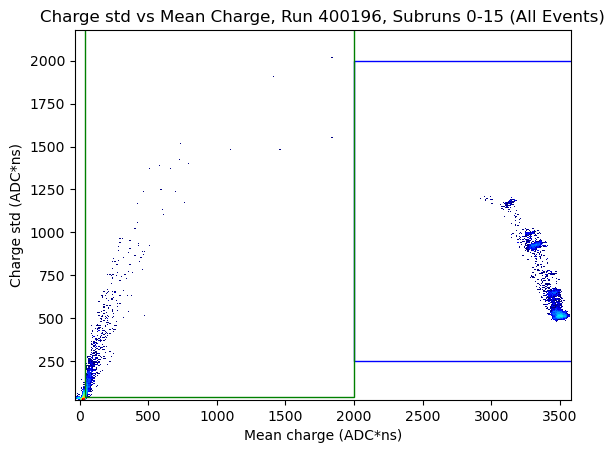

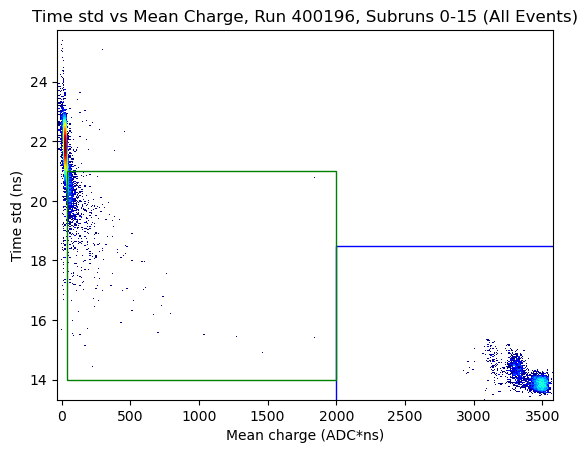

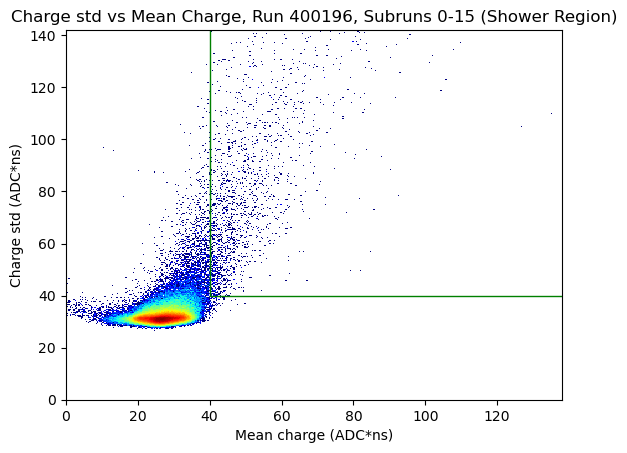

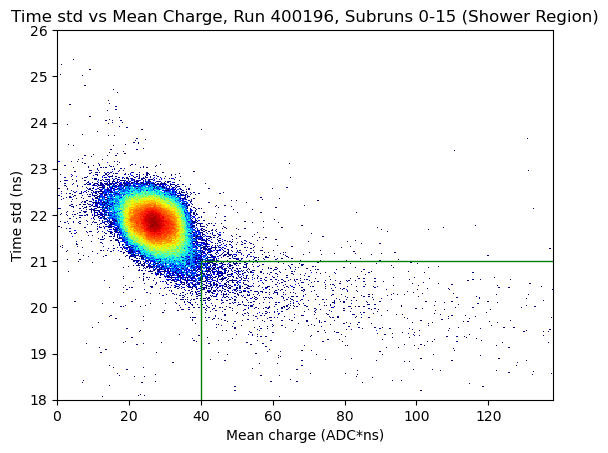

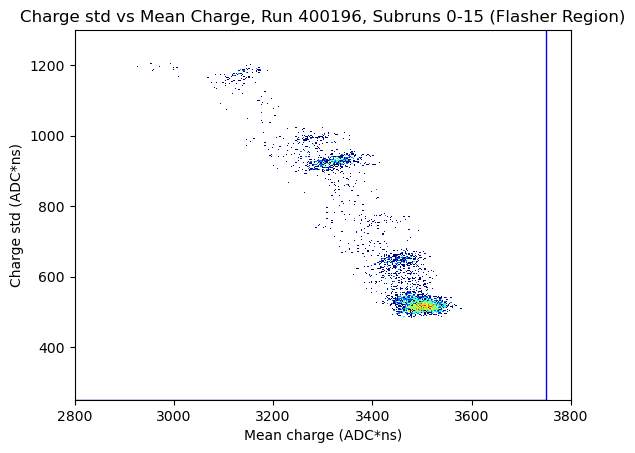

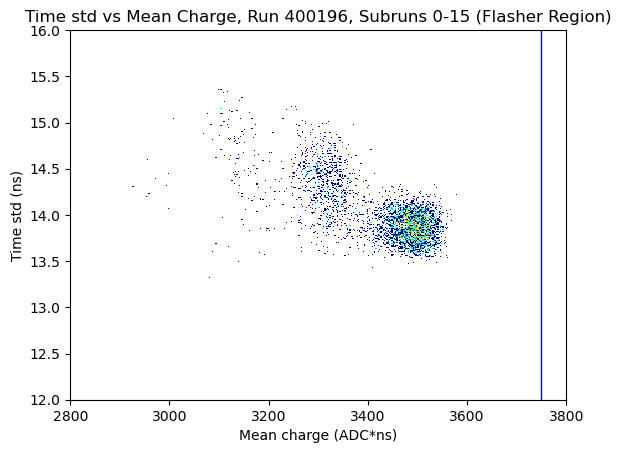

In [45]:
#2d histogram testing
cuts=fixed_cuts()
current_sr=[400196, 15]
sorting_hists_2d(cuts, current_sr, sorted_run_data, sr_data, "/data/user/fbivens5020/DQM_scripts/DQM_plots/display_plots/", "/data/user/fbivens5020/DQM_scripts/DQM_plots/subrun_plots", subrun_plots=False, boxes=True, regions=True, flashers=True, tight=True)

In [52]:
#event visualizer tester thing 
from psct_event_visualizer import display_event, get_reader_object, get_event_from_reader # Uses target_io and csv, as well as numpy and matplotlib of course

def visualizer_img_display(run_id, subrun_id, event_id):
   filename = '/data/user/fbivens5020/mock_data/run'+str(run_id)+'_subrun'+str(int(subrun_id))+'.r1' # Using the first light file as an example. This path is correct if you are running this at the UW-Madison clusters then this is the right path
   wfs = None # The utility of this line will become clear

   fig, axs, wfs = display_event(filename, 
                              event = int(event_id), # If not provided, plots event 0
                            #   title="Run 400006 Event 121", # Title. if nto provided, it leaves it in blank
                            #   font = 6, # Font for all labels. If not provided, fetches from config file
                              wfs = wfs, display= False
                              )
   
   for wf in wfs:
      for w in wf:
        for channel in range(16):
            w[5][channel]=0
   fig, axs, wfs = display_event(filename, 
                              event = int(event_id), # If not provided, plots event 0
                              title="Run "+str(run_id)+" Sub-Run "+str(subrun_id)+" Event "+str(int(event_id)), # Title. if nto provided, it leaves it in blank
                            #   font = 6, # Font for all labels. If not provided, fetches from config file
                              wfs = wfs
                              )

   plt.show()
   plt.close()

In [55]:
#zone sorter and visualization creator since the sorting takes 0.2s. 
#use to pick small zones and get random events from those zones for checking purposes
zone11=[]
zone12=[]
zone13=[]
zone14=[]
zone21=[]
zone22=[]
zone23=[]
zone24=[]

noise_sample=[]
low_shower_sample=[]
high_shower_sample=[]
flasher_sample=[]

for event in range(len(sorted_run_data[0][0])):
    if sorted_run_data[0][2][event]>cuts[4] and sorted_run_data[0][2][event]<cuts[3] and sorted_run_data[0][3][event]>cuts[9] and sorted_run_data[0][3][event]<(cuts[9]+10):
        zone11.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>cuts[3] and sorted_run_data[0][2][event]<(cuts[3]+10) and sorted_run_data[0][3][event]>cuts[9] and sorted_run_data[0][3][event]<(cuts[9]+10):
        zone12.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>cuts[4] and sorted_run_data[0][2][event]<cuts[3] and sorted_run_data[0][3][event]>cuts[10] and sorted_run_data[0][3][event]<cuts[9]:
        zone13.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>cuts[3] and sorted_run_data[0][2][event]<(cuts[3]+10) and sorted_run_data[0][3][event]>cuts[10] and sorted_run_data[0][3][event]<cuts[9]:
        zone14.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])


    if sorted_run_data[0][2][event]>cuts[4] and sorted_run_data[0][2][event]<cuts[3] and sorted_run_data[0][5][event]>cuts[14] and sorted_run_data[0][5][event]<cuts[17]:
        zone21.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>cuts[3] and sorted_run_data[0][2][event]<(cuts[3]+10) and sorted_run_data[0][5][event]>cuts[14] and sorted_run_data[0][5][event]<cuts[17]:
        zone22.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>cuts[4] and sorted_run_data[0][2][event]<cuts[3] and sorted_run_data[0][5][event]>(cuts[14]-1) and sorted_run_data[0][5][event]<cuts[14]:
        zone23.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>cuts[3] and sorted_run_data[0][2][event]<(cuts[3]+10) and sorted_run_data[0][5][event]>(cuts[14]-1) and sorted_run_data[0][5][event]<cuts[14]:
        zone24.append([sorted_run_data[0][0][event],sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>20 and sorted_run_data[0][2][event]<25 and sorted_run_data[0][3][event]>30 and sorted_run_data[0][3][event]<32:
        noise_sample.append([sorted_run_data[0][0][event], sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>40 and sorted_run_data[0][2][event]<60 and sorted_run_data[0][3][event]>60 and sorted_run_data[0][3][event]<80:
        low_shower_sample.append([sorted_run_data[0][0][event], sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>1300 and sorted_run_data[0][2][event]<2000 and sorted_run_data[0][3][event]>1250 and sorted_run_data[0][3][event]<2500:
        high_shower_sample.append([sorted_run_data[0][0][event], sorted_run_data[0][6][event]])

    if sorted_run_data[0][2][event]>3400 and sorted_run_data[0][2][event]<3600 and sorted_run_data[0][3][event]>400 and sorted_run_data[0][3][event]<800:
        flasher_sample.append([sorted_run_data[0][0][event], sorted_run_data[0][6][event]])

#print(f'Lengths:\nzone 11: {len(zone11)}\nzone 12: {len(zone12)}\nzone 13: {len(zone13)}\nzone 14: {len(zone14)}\nzone 21: {len(zone21)}\nzone 22: {len(zone22)}\nzone 23: {len(zone23)}\nzone 24: {len(zone24)}')
run_id=400215
target=low_shower_sample
for image in range(5):
     event=np.random.randint(len(target))
     subrun_id=target[event][1]
     event_id=target[event][0]
     visualizer_img_display(run_id, subrun_id, event_id)


test successful
test successful
[WaveformArrayReader] Path: /data/user/fbivens5020/mock_data/run400215_subrun12.r1
[WaveformArrayReader] CameraVersion: 1.1.0
[WaveformArrayReader] IsR1: 1
[WaveformArrayReader] NModules: 25
[WaveformArrayReader] ActiveModuleSlots: 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
[WaveformArrayReader] NPixels: 1600
[WaveformArrayReader] SkipEvents: 0
[WaveformArrayReader] SkipEndEvents: 0
[WaveformArrayReader] NEvents: 20317
[WaveformArrayReader] NSamples: 64


: 

In [ ]:
#zone percentage estimates very important don't want to have to do again
zone11_results=[4/5, 3/5, 3/5]
print(f'\nzone 11 avg shower percentage: {np.mean(zone11_results)*100}%, std: {np.std(zone11_results)}, confidence: {(15/len(zone11))*100}%')

zone12_results=[3/5, 4/5, 5/5]
print(f'\nzone 12 avg shower percentage: {np.mean(zone12_results)*100}%, std: {np.std((zone12_results))}, confidence: {(15/len(zone12))*100}%')

zone13_results=[0/5, 2/5, 1/5]
print(f'\nzone 13 avg shower percentage: {np.mean(zone13_results)*100}%, std: {np.std((zone13_results))}, confidence: {(15/len(zone13))*100}%')

zone14_results=[1/5,3/5,3/5]
print(f'\nzone 14 avg shower percentage: {np.mean(zone14_results)*100}%, std: {np.std((zone14_results))}, confidence: {(15/len(zone14))*100}%')

zone21_results=[2/5,2/5,1/5]
print(f'\nzone 21 avg shower percentage: {np.mean(zone21_results)*100}%, std: {np.std((zone21_results))}, confidence: {(15/len(zone21))*100}%')

zone22_results=[4/5,2/5,2/5]
print(f'\nzone 22 avg shower percentage: {np.mean(zone22_results)*100}%, std: {np.std((zone22_results))}, confidence: {(15/len(zone22))*100}%')

zone23_results=[3/5,3/5,3/5]
print(f'\nzone 23 avg shower percentage: {np.mean(zone23_results)*100}%, std: {np.std((zone23_results))}, confidence: {(15/len(zone23))*100}%')

zone24_results=[5/5,4/5,5/5]
print(f'\nzone 24 avg shower percentage: {np.mean(zone24_results)*100}%, std: {np.std((zone24_results))}, confidence: {(15/len(zone24))*100}%')


zone 11 avg shower percentage: 66.66666666666666%, std: 0.09428090415820636, confidence: 1.467710371819961%

zone 12 avg shower percentage: 80.0%, std: 0.16329931618554522, confidence: 1.9920318725099602%

zone 13 avg shower percentage: 20.000000000000004%, std: 0.16329931618554522, confidence: 0.05240357741755171%

zone 14 avg shower percentage: 46.666666666666664%, std: 0.18856180831641264, confidence: 2.0188425302826376%

zone 21 avg shower percentage: 33.33333333333333%, std: 0.09428090415820635, confidence: 0.04654193428278879%

zone 22 avg shower percentage: 53.333333333333336%, std: 0.18856180831641267, confidence: 1.1867088607594938%

zone 23 avg shower percentage: 60.0%, std: 0.0, confidence: 1.3020833333333335%

zone 24 avg shower percentage: 93.33333333333333%, std: 0.09428090415820632, confidence: 1.2185215272136474%


In [42]:
# new 1d hist function
def sorting_hists_1d(cuts, current_sr, sorted_run_data, sr_data, display_plots_path, plots_save_path, subrun_plots=False, boxes=True, regions=True, flashers=True):
    fig=plt.figure()
    ax=fig.add_subplot(111)
    ax.hist(sorted_run_data[0][2], bins = 400, log=True)

    if boxes==True:
        ax.add_patch(patches.Rectangle(xy=(cuts[0],0), width=(cuts[1]-cuts[0]), height=(1400), linewidth=1, color='green', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[0]-50,0), width=(50), height=(1400), linewidth=1, color='orange', fill=False))
        ax.add_patch(patches.Rectangle(xy=(cuts[0],0), width=(50), height=(1400), linewidth=1, color='blue', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[4],0), width=(cuts[5]-cuts[4]), height=(1400), linewidth=1, color='red', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[4]+250,0), width=(500), height=(1400), linewidth=1, color='purple', fill=False))

    ax.set_title(f"Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (All Events)")
    ax.set_xlabel("Mean charge (ADC*ns)")
    ax.set_ylabel("Counts")
    # fig.savefig(f'{display_plots_path}charge_mean_histogram.jpg')
    # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_mean_histogram.jpg')
    plt.show()

    fig=plt.figure()
    ax=fig.add_subplot(111)
    ax.hist(sorted_run_data[0][3], bins = 400, log=True)

    if boxes==True:
        ax.add_patch(patches.Rectangle(xy=(cuts[2],0), width=(cuts[3]-cuts[2]), height=(1400), linewidth=1, color='green', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[2]-50,0), width=(50), height=(1400), linewidth=1, color='orange', fill=False))
        ax.add_patch(patches.Rectangle(xy=(cuts[2],0), width=(50), height=(1400), linewidth=1, color='blue', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[6],0), width=(cuts[7]-cuts[6]), height=(1400), linewidth=1, color='red', fill=False))
        ax.add_patch(patches.Rectangle(xy=(cuts[6]+250,0), width=(250), height=(1400), linewidth=1, color='purple', fill=False))

    ax.set_title(f"Charge Std, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (All Events)")
    ax.set_xlabel("Charge Std (ADC*ns)")
    ax.set_ylabel("Counts")
    # fig.savefig(f'{display_plots_path}charge_std_histogram.jpg')
    # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_histogram.jpg')
    plt.show()

    fig=plt.figure()
    ax=fig.add_subplot(111)
    ax.hist(sorted_run_data[0][4], bins = 400, log=True)
    ax.set_title(f"Mean Peak Time, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (All Events)")
    ax.set_xlabel("Mean Peak Time (ns)")
    ax.set_ylabel("Counts")
    # fig.savefig(f'{display_plots_path}time_mean_histogram.jpg')
    # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_mean_histogram.jpg')
    plt.show()

    fig=plt.figure()
    ax=fig.add_subplot(111)
    ax.hist(sorted_run_data[0][5], bins = 400, log=True)

    if boxes==True:
        ax.add_patch(patches.Rectangle(xy=(cuts[8],0), width=(cuts[9]-cuts[8]), height=(1400), linewidth=1, color='green', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[9],0), width=(1), height=(1400), linewidth=1, color='orange', fill=False))
        ax.add_patch(patches.Rectangle(xy=(cuts[9]-1,0), width=(1), height=(1400), linewidth=1, color='blue', fill=False))

        ax.add_patch(patches.Rectangle(xy=(cuts[10],0), width=(cuts[11]-cuts[10]), height=(1400), linewidth=1, color='red', fill=False))
        ax.add_patch(patches.Rectangle(xy=(cuts[10]+1,0), width=(1.5), height=(1400), linewidth=1, color='purple', fill=False))

    ax.set_title(f"Peak Time Std, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (All Events)")
    ax.set_xlabel("Peak Time Std (ns)")
    ax.set_ylabel("Counts")
    # fig.savefig(f'{display_plots_path}time_std_histogram.jpg')
    # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_std_histogram.jpg')
    plt.show()

    if regions==True:
        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sorted_run_data[0][2], bins = 400, log=True, range=(0, 800))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(40,0), width=(760), height=(1400), linewidth=1, color='green', fill=False))
            # ax.add_patch(patches.Rectangle(xy=(cuts[0]-100,0), width=(100), height=(1400), linewidth=1, color='orange', fill=False))
            # ax.add_patch(patches.Rectangle(xy=(cuts[0],0), width=(100), height=(1400), linewidth=1, color='blue', fill=False))

        ax.set_title(f"Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Shower Region)")
        ax.set_xlabel("Mean Charge (ADC*ns)")
        ax.set_ylabel("Counts")
        # fig.savefig(f'{display_plots_path}charge_mean_shower_region_histogram.jpg')
        # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_mean_shower_region_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sorted_run_data[0][3], bins = 400, log=True, range=(0,500))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(40,0), width=(460), height=(1400), linewidth=1, color='green', fill=False))
            # ax.add_patch(patches.Rectangle(xy=(cuts[2]-100,0), width=(100), height=(1400), linewidth=1, color='orange', fill=False))
            # ax.add_patch(patches.Rectangle(xy=(cuts[2],0), width=(100), height=(1400), linewidth=1, color='blue', fill=False))

        ax.set_title(f"Charge Std, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Shower Region)")
        ax.set_xlabel("Charge Std (ADC*ns)")
        ax.set_ylabel("Counts")
        # fig.savefig(f'{display_plots_path}charge_std_shower_region_histogram.jpg')
        # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_shower_region_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sorted_run_data[0][5], bins = 400, log=True, range=(16, 22))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(16,0), width=(5), height=(1400), linewidth=1, color='green', fill=False))
            # ax.add_patch(patches.Rectangle(xy=(cuts[9],0), width=(1), height=(1400), linewidth=1, color='orange', fill=False))
            # ax.add_patch(patches.Rectangle(xy=(cuts[9]-1,0), width=(1), height=(1400), linewidth=1, color='blue', fill=False))

        ax.set_title(f"Peak Time Std, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Shower Region)")
        ax.set_xlabel("Peak Time Std (ns)")
        ax.set_ylabel("Counts")
        # fig.savefig(f'{display_plots_path}time_std_shower_region_histogram.jpg')
        # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_std_shower_region_histogram.jpg')
        plt.show()

    if flashers==True:
        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sorted_run_data[0][2], bins = 400, log=True, range=(cuts[4]-50, cuts[5]+50))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[4],0), width=(cuts[5]-cuts[4]), height=(1400), linewidth=1, color='red', fill=False))

        ax.set_title(f"Mean Charge, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Flasher Region)")
        ax.set_xlabel("Mean Charge (ADC*ns)")
        ax.set_ylabel("Counts")
        # fig.savefig(f'{display_plots_path}charge_mean_flasher_region_histogram.jpg')
        # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_mean_flasher_region_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sorted_run_data[0][3], bins = 400, log=True, range=(cuts[6]-50,cuts[7]+50))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[6],0), width=(cuts[7]-cuts[6]), height=(1400), linewidth=1, color='red', fill=False))

        ax.set_title(f"Charge Std, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Flasher Region)")
        ax.set_xlabel("Charge Std (ADC*ns)")
        ax.set_ylabel("Counts")
        # fig.savefig(f'{display_plots_path}charge_std_flasher_region_histogram.jpg')
        # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_charge_std_flasher_region_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sorted_run_data[0][5], bins = 400, log=True, range=(cuts[10]-3, cuts[11]+3))

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[10],0), width=(cuts[11]-cuts[10]), height=(1400), linewidth=1, color='red', fill=False))

        ax.set_title(f"Peak Time Std, Run {current_sr[0]}, Subruns 0-{current_sr[1]} (Flasher Region)")
        ax.set_xlabel("Peak Time Std (ns)")
        ax.set_ylabel("Counts")
        # fig.savefig(f'{display_plots_path}time_std_flasher_region_histogram.jpg')
        # fig.savefig(f'{plots_save_path}run_{current_sr[0]}_time_std_flasher_region_histogram.jpg')
        plt.show()

    if subrun_plots==True:
        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sr_data[3], bins = 400, log=True)

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[0],0), width=(cuts[1]-cuts[0]), height=(1400), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[4],0), width=(cuts[5]-cuts[4]), height=(1400), linewidth=1, color='red', fill=False))

        ax.set_title(f"Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (All Events)")
        ax.set_xlabel("Mean charge (ADC*ns)")
        ax.set_ylabel("Counts")
        fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_mean_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sr_data[4], bins = 400, log=True)

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[2],0), width=(cuts[3]-cuts[2]), height=(1400), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[6],0), width=(cuts[7]-cuts[6]), height=(1400), linewidth=1, color='red', fill=False))

        ax.set_title(f"Charge Std, Run {current_sr[0]}, Subrun {current_sr[1]} (All Events)")
        ax.set_xlabel("Charge Std (ADC*ns)")
        ax.set_ylabel("Counts")
        fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_std_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sr_data[1], bins = 400, log=True)
        ax.set_title(f"Mean Peak Time, Run {current_sr[0]}, Subrun {current_sr[1]} (All Events)")
        ax.set_xlabel("Mean Peak Time (ns)")
        ax.set_ylabel("Counts")
        fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_mean_histogram.jpg')
        plt.show()

        fig=plt.figure()
        ax=fig.add_subplot(111)
        ax.hist(sr_data[2], bins = 400, log=True)

        if boxes==True:
            ax.add_patch(patches.Rectangle(xy=(cuts[8],0), width=(cuts[9]-cuts[8]), height=(1400), linewidth=1, color='green', fill=False))
            ax.add_patch(patches.Rectangle(xy=(cuts[10],0), width=(cuts[11]-cuts[10]), height=(1400), linewidth=1, color='red', fill=False))

        ax.set_title(f"Peak Time Std, Run {current_sr[0]}, Subruns {current_sr[1]} (All Events)")
        ax.set_xlabel("Peak Time Std (ns)")
        ax.set_ylabel("Counts")
        fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_std_histogram.jpg')
        plt.show()

        if regions==True:
            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist(sr_data[3], bins = 400, log=True, range=(cuts[0]-50, cuts[1]+50))

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[0],0), width=(cuts[1]-cuts[0]), height=(1400), linewidth=1, color='green', fill=False))

            ax.set_title(f"Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (Shower Region)")
            ax.set_xlabel("Mean Charge (ADC*ns)")
            ax.set_ylabel("Counts")
            fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_mean_shower_region_histogram.jpg')
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist(sr_data[4], bins = 400, log=True, range=(cuts[2]-50,cuts[3]+50))

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[2],0), width=(cuts[3]-cuts[2]), height=(1400), linewidth=1, color='green', fill=False))

            ax.set_title(f"Charge Std, Run {current_sr[0]}, Subrun {current_sr[1]} (Shower Region)")
            ax.set_xlabel("Charge Std (ADC*ns)")
            ax.set_ylabel("Counts")
            fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_std_shower_region_histogram.jpg')
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist(sr_data[2], bins = 400, log=True, range=(cuts[8]-3, cuts[9]+3))

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[8],0), width=(cuts[9]-cuts[8]), height=(1400), linewidth=1, color='green', fill=False))

            ax.set_title(f"Peak Time Std, Run {current_sr[0]}, Subrun {current_sr[1]} (Shower Region)")
            ax.set_xlabel("Peak Time Std (ns)")
            ax.set_ylabel("Counts")
            fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_std_shower_region_histogram.jpg')
            plt.show()

        if flashers==True:
            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist(sr_data[3], bins = 400, log=True, range=(cuts[4]-50, cuts[5]+50))

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[4],0), width=(cuts[5]-cuts[4]), height=(1400), linewidth=1, color='red', fill=False))

            ax.set_title(f"Mean Charge, Run {current_sr[0]}, Subrun {current_sr[1]} (Flasher Region)")
            ax.set_xlabel("Mean Charge (ADC*ns)")
            ax.set_ylabel("Counts")
            fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_mean_flasher_region_histogram.jpg')
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist(sr_data[4], bins = 400, log=True, range=(cuts[6]-50,cuts[7]+50))

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[6],0), width=(cuts[7]-cuts[6]), height=(1400), linewidth=1, color='red', fill=False))

            ax.set_title(f"Charge Std, Run {current_sr[0]}, Subrun {current_sr[1]} (Flasher Region)")
            ax.set_xlabel("Charge Std (ADC*ns)")
            ax.set_ylabel("Counts")
            fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_charge_std_flasher_region_histogram.jpg')
            plt.show()

            fig=plt.figure()
            ax=fig.add_subplot(111)
            ax.hist(sr_data[2], bins = 400, log=True, range=(cuts[10]-3, cuts[11]+3))

            if boxes==True:
                ax.add_patch(patches.Rectangle(xy=(cuts[10],0), width=(cuts[11]-cuts[10]), height=(1400), linewidth=1, color='red', fill=False))

            ax.set_title(f"Peak Time Std, Run {current_sr[0]}, Subrun {current_sr[1]} (Flasher Region)")
            ax.set_xlabel("Peak Time Std (ns)")
            ax.set_ylabel("Counts")
            fig.savefig(f'{plots_save_path}run_{current_sr[0]}_subrun_{current_sr[1]}_time_std_flasher_region_histogram.jpg')
            plt.show()

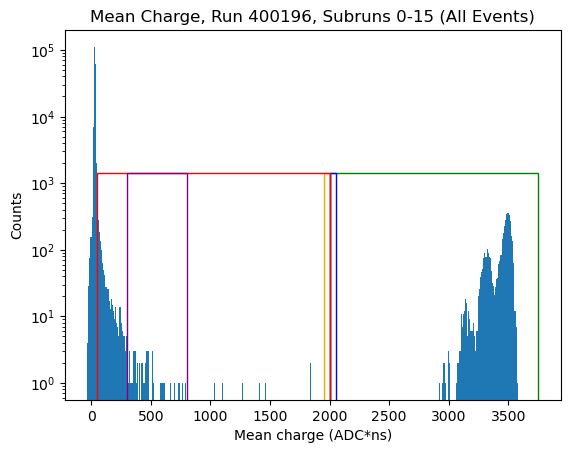

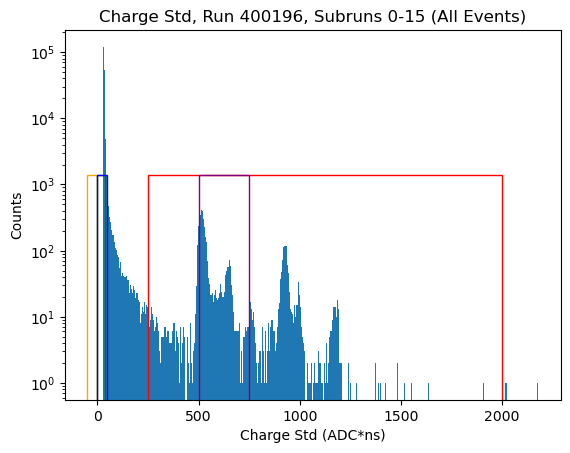

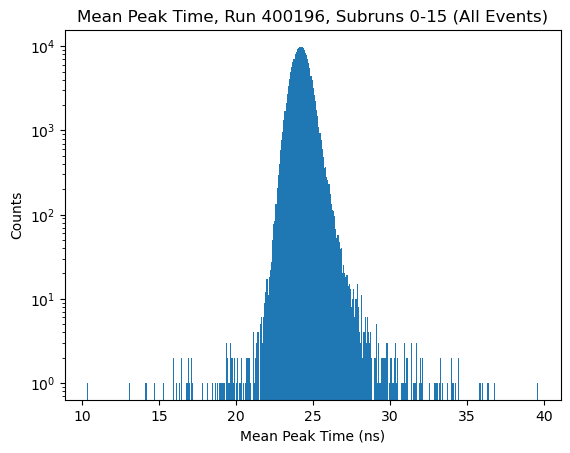

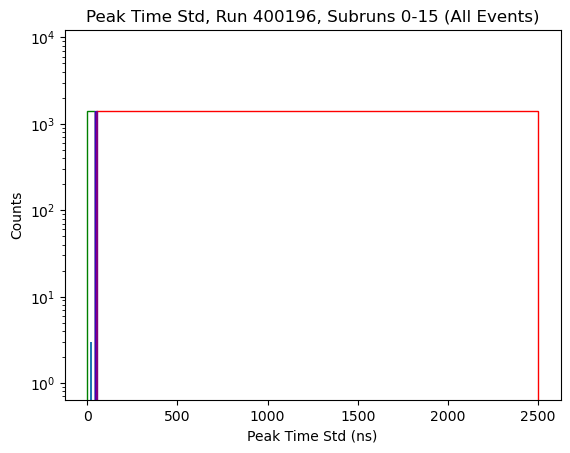

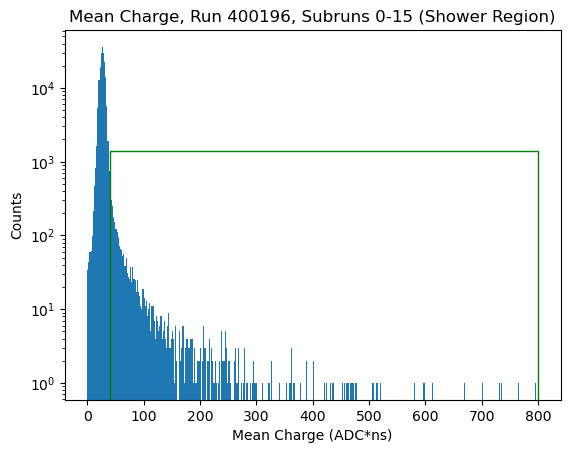

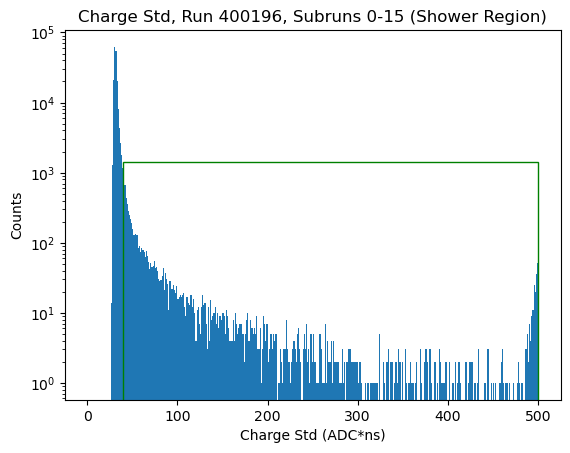

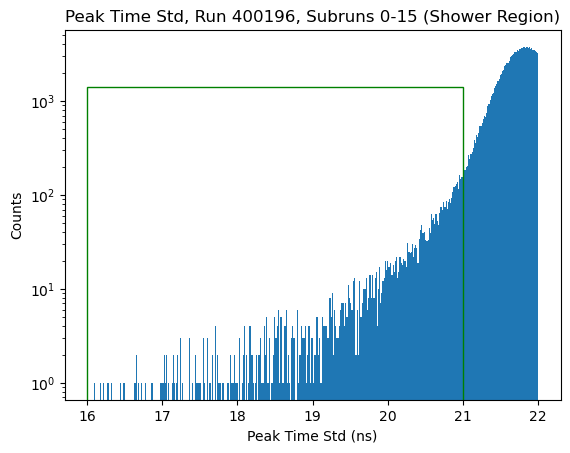

In [43]:
#1d hist function testing
sorting_hists_1d(cuts, current_sr, sorted_run_data, sr_data, "/data/user/fbivens5020/DQM_Plots/DQM_display_plots/", "/data/user/fbivens5020/DQM_Plots/", subrun_plots=False, boxes=True, regions=True, flashers=False)

In [ ]:
#end of testing hell sequence, new physical metrics function:

def physical_summary(current_sr, run_data, physical_metrics_location, display_plots_path, plots_save_path, time_step, modules=22):
    
    fpmTemp_list=[]
    feeTemp_list=[]
    hv_list=[]
    current_list=[]

    for sr in range(current_sr[1]+1):

      fpmTemp_data=np.load(f'{physical_metrics_location}temperatures_FPMs_run{current_sr[0]}_subrun{sr}.npy')
      fpmTemp_list.append(fpmTemp_data)

      feeTemp_data=np.load(f'{physical_metrics_location}temperatures_FEEs_run{current_sr[0]}_subrun{sr}.npy')
      feeTemp_list.append(feeTemp_data)

      hv_data=np.load(f'{physical_metrics_location}HV_FPMs_run{current_sr[0]}_subrun{sr}.npy')
      hv_list.append(hv_data)

      current_data=np.load(f'{physical_metrics_location}Current_FEEs_run{current_sr[0]}_subrun{sr}.npy')
      current_list.append(current_data)

    fpmTemps=np.zeros((modules*4,4,len(fpmTemp_list[:])))
    feeTemps=np.zeros((modules*2,4,len(feeTemp_list[:])))
    hv=np.zeros((modules,4,len(hv_list[:])))
    current=np.zeros((modules,4,len(current_list[:])))

    for sr in range(current_sr[1]+1):

        for quad in range(modules*4):
           fpmTemps[quad][0][sr]=sr
           fpmTemps[quad][1][sr]=fpmTemp_list[sr][quad]
           fpmTemps[quad][2][sr]=quad//4
           fpmTemps[quad][3][sr]=run_data[sr][5][0]

        for board in range(modules*2):
           feeTemps[board][0][sr]=sr
           feeTemps[board][1][sr]=feeTemp_list[sr][board]
           feeTemps[board][2][sr]=board//2
           feeTemps[board][3][sr]=run_data[sr][5][0]

        for mod in range(modules):
           hv[mod][0][sr]=sr
           hv[mod][1][sr]=hv_list[sr][mod]
           hv[mod][2][sr]=mod
           hv[mod][3][sr]=run_data[sr][5][0]
           current[mod][0][sr]=sr
           current[mod][1][sr]=current_list[sr][mod]
           current[mod][2][sr]=mod
           current[mod][3][sr]=run_data[sr][5][0]

    fig, (ax1,ax2,ax3,ax4)=plt.subplots(4,1)

    for quad in range(modules*4):
       ax1.plot(fpmTemps[quad][3]/(time_step), fpmTemps[quad][1])
    ax1.set_ylabel("FPM Temp (C)")

    for board in range(modules*2):
       ax2.plot(feeTemps[board][3]/(time_step), feeTemps[board][1])
    ax2.set_ylabel("FEE Temp (C)")

    for mod in range(modules):
       ax3.plot(hv[mod][3]/(time_step),hv[mod][1])
       ax4.plot(current[mod][3]/(time_step),current[mod][1])
    ax3.set_ylabel("HV (V)")
    ax4.set_ylabel("Current (A)")
    ax4.set_xlabel("Time (min)")
    fig.tight_layout()
    #fig.set_label(f"Run {current_sr[0]}, Subruns 0-{current_sr[1]}, Physical Metrics") #should be a title for the thing, not currently working
    fig.savefig(f'{display_plots_path}physical_metrics_plots.jpg')
    fig.savefig(f'{plots_save_path}run_{current_sr[0]}_physical_metrics.jpg')
    plt.show()

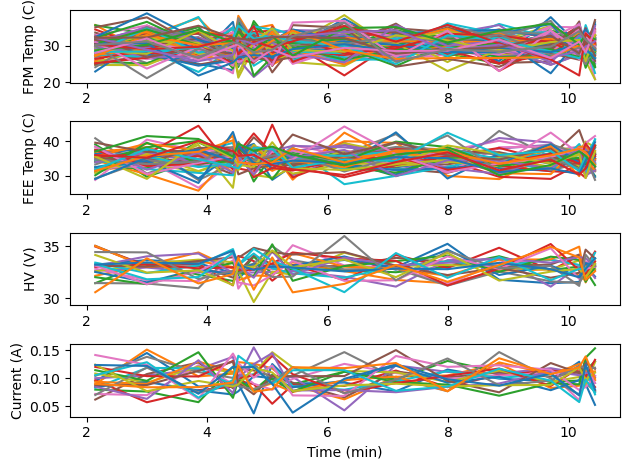

In [13]:
physical_summary(current_sr, run_data, '/data/user/fbivens5020/mock_data/', "/data/user/fbivens5020/DQM_Plots/DQM_display_plots/", "/data/user/fbivens5020/DQM_Plots/", 60E9, modules=22)